# **FUNCTIONAL ANALYSIS OF BOOLEVARD OUTPUT**

#### **Background**

In this notebook, we analyze the output generated by BooLEVARD, consisting of path counts toward every node in the Boolean models. 

As a first step, we perform KEGG pathway enrichment analysis to identify pathways that are significantly over-represented among the model nodes. Based on these results, we retain the enriched pathways for downstream analyses. 

Next, pathway-level scores are computed according to Equations 1-2, summarizing the contribution of individual nodes to each pathway. Finally, these pathway scores are used to perform a principal component analysis (PCA) across double-perturbed model instances that were classified as true positives. 

$$
X_i \;=\;
\frac{\operatorname{sign}(p_i)\,\log\!\left(1+|p_i|\right)}
{\sum_{j \in \mathcal{N}} \left|\operatorname{sign}(p_j)\,\log\!\left(1+|p_j|\right)\right|}
\tag{1}
$$

Here, $p_i$ denotes the signed path count leading to the local state of node $i$, averaged across the stable states of a given Boolean model. Equation (1) defines a normalized node-level score $X_i$, obtained by applying a signed logarithmic transformation to $p_i$ and normalizing by the total absolute signal across all nodes in the model.

$$
S_k \;=\; \operatorname{median}\!\left\{\, X_i \;:\; i \in \mathcal{N}_k \,\right\}
\tag{2}
$$

In Equation (2), $\mathcal{N}_p$ denotes the set of model nodes annotated to pathway $p$. The pathway score $S_k$ is computed as the median of the node-level scores $X_i$ associated with that pathway, providing a robust summary of pathway-level activity.


In [ ]:
import os
import json
import shutil
import tempfile
import zipfile
import boolevard as blv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
import seaborn as sns
import textwrap
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import fcluster, leaves_list, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ranksums, hypergeom, kruskal, mannwhitneyu
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple
from matplotlib.patches import Patch
from sklearn.metrics.pairwise import cosine_distances
from itertools import combinations

In [4]:
# ── Paths ──
bless_out  = "/mnt/Datos/Project_VBP/paper/results/bless_output/data_vis"
excel_path = "/mnt/Datos/Project_VBP/paper/results/functional_bless.xlsx"

# ── Drug metadata ──
drug_map = {
    "PD_01": "BCL2i",  "PD_02": "EGFRi", "PD_03": "ERBBi", "PD_05": "FGFRi",
    "PD_06": "AKTi",   "PD_07": "CDKi",  "PD_08": "PI3Ki", "PD_09": "METi",
    "PD_10": "MEKi",   "PD_11": "RAFi",  "PD_12": "IGFRi", "PD_13": "ERKi",
    "PD_14": "MTORi",  "PD_15": "PORCNi",
}
drug_pathways = {
    "PD_01": "Apoptosis", "PD_02": "RTK",      "PD_03": "RTK",      "PD_05": "RTK",
    "PD_09": "RTK",       "PD_12": "RTK",      "PD_07": "Cell cycle","PD_06": "AKT/MTOR",
    "PD_08": "AKT/MTOR",  "PD_14": "AKT/MTOR", "PD_10": "MAPK",    "PD_11": "MAPK",
    "PD_13": "MAPK",      "PD_15": "WNT",
}

#### **1.- Preprocess BooLEVARD's outputs**

In [ ]:
def _extract_and_sanitize(zip_path, prefix):
    """Extract a file matching *prefix* from a zip, fix column counts, return a DataFrame."""
    with zipfile.ZipFile(zip_path, "r") as z:
        target = next(n for n in z.namelist() if n.startswith(prefix))
        tmpdir = tempfile.mkdtemp()
        path = z.extract(target, tmpdir)
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        header = f.readline().rstrip("\n\t")
        ncols = header.count("\t") + 1
        lines = [header]
        for line in f:
            parts = line.rstrip("\n").split("\t")
            parts = (parts + ["NA"] * ncols)[:ncols]
            lines.append("\t".join(parts))
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")
    df = pd.read_csv(path, sep="\t", na_values=["NA"]).dropna()
    shutil.rmtree(tmpdir)
    return df


def _iter_archives(bless_out):
    """Yield (tissue, cell_line, zip_path) for every archive."""
    for tissue in sorted(os.listdir(bless_out)):
        tdir = os.path.join(bless_out, tissue)
        if not os.path.isdir(tdir):
            continue
        for cl in sorted(os.listdir(tdir)):
            if os.path.isfile(os.path.join(tdir, cl)):
                yield tissue, cl.replace(".zip", ""), os.path.join(tdir, cl)

#### **1.1.- Synergies**

For every cell-line archive we extract the *SynergyExcess* file, sanitize column counts, and concatenate into a single table.

In [ ]:
rows = []
for tissue, cl, zpath in _iter_archives(bless_out):
    df = _extract_and_sanitize(zpath, "Results/SynergyExcess")
    df["cell_line"], df["tissue"] = cl, tissue
    rows.append(df)
syn_all = pd.concat(rows, ignore_index=True)

with pd.ExcelWriter(excel_path, engine="openpyxl",
                     mode="a" if os.path.exists(excel_path) else "w",
                     if_sheet_exists="replace") as w:
    syn_all.to_excel(w, sheet_name="synergies", index=False)

#### **1.2.- Path counts (all nodes)**

For each archive we extract *PathCountsFull*, average across stable states, apply the signed-log normalization (Eq. 1), then average across models sharing the same perturbation label.

In [ ]:
_DROP_SUFFIXES = ("_iCOND", "_INH", "_ACT", "_MEDIA")

rows = []
for tissue, cl, zpath in _iter_archives(bless_out):
    df = _extract_and_sanitize(zpath, "Results/PathCountsFull_")
    # Remove duplicate columns and SS, then average across stable states
    df = (df.loc[:, ~df.columns.str.endswith(".1")]
            .drop(columns=["SS"])
            .groupby("Model ID", as_index=False).mean())
    # Drop condition / perturbation indicator columns
    keep = [c for c in df.columns if not c.endswith(_DROP_SUFFIXES)]
    df = df[keep]
    # Signed-log normalisation (Eq. 1)
    X = df.set_index("Model ID")
    X = np.sign(X) * np.log1p(np.abs(X))
    X = X.div(X.abs().sum(axis=1).replace(0, np.nan), axis=0)
    # Average per perturbation
    X = X.reset_index()
    X["perturbation"] = X["Model ID"].str.extract(r"(PD_\d+(?:_PD_\d+)*)", expand=False).fillna("UNPERTURBED")
    X = X.drop(columns=["Model ID"]).groupby("perturbation", as_index=False).mean(numeric_only=True)
    X.insert(0, "tissue", tissue)
    X.insert(1, "cell_line", cl)
    rows.append(X)

X_all = pd.concat(rows, ignore_index=True)

with pd.ExcelWriter(excel_path, engine="openpyxl",
                     mode="a" if os.path.exists(excel_path) else "w",
                     if_sheet_exists="replace") as w:
    X_all.to_excel(w, sheet_name="preliminary", index=False)

#### **2.- KEGG pathway annotation and scoring**
Normalized node-level scores are aggregated into pathway-level scores using KEGG annotations. Pathway scores are computed as the median of node scores annotated to each pathway (Eq. 2). The pathway space is restricted to enriched KEGG pathways (hypergeometric test, FDR < 0.01), excluding disease-specific and context-dependent annotations.

In [5]:
# ── Inputs ──
nodeHGNC = pd.read_csv("/mnt/Datos/Project_VBP/paper/src/NodeHGNC.csv")
kegg     = pd.read_csv("/mnt/Datos/Project_VBP/paper/src/kegg_pathway.csv")
counts   = pd.read_excel(excel_path, sheet_name="preliminary")

##### **2.1.- Hypergeometric enrichment of KEGG pathways**

In [6]:
MIN_OVERLAP, MIN_PW_SIZE = 3, 5

nodeHGNC["HGNC_symbol"] = nodeHGNC["HGNC_symbol"].astype(str).str.replace(r"[\[\]']", "", regex=True)
model_genes = set(nodeHGNC["HGNC_symbol"].dropna().unique())
universe    = set(kegg["HGNC"].dropna().astype(str).unique())
foreground  = model_genes & universe
N, n = len(universe), len(foreground)

kegg_u = kegg.copy()
kegg_u["HGNC"] = kegg_u["HGNC"].astype(str)
pw_sets = kegg_u[kegg_u["HGNC"].isin(universe)].groupby(["Pathway_ID", "Pathway_Name"])["HGNC"].apply(lambda s: set(s.dropna().unique()))

rows = []
for (pid, pname), genes in pw_sets.items():
    K, k = len(genes), len(genes & foreground)
    if K >= MIN_PW_SIZE and k >= MIN_OVERLAP:
        rows.append(dict(Pathway_ID=pid, Pathway_Name=pname, k=k, K=K, N=N, n=n,
                         pval=hypergeom.sf(k - 1, N, K, n)))

enrich_df = pd.DataFrame(rows).sort_values("pval")
enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1] if len(enrich_df) else []

# Exclude disease / context-specific pathways
GENERIC_PATHWAYS = {
    "Pathways in cancer","Colorectal cancer","Endometrial cancer","Prostate cancer",
    "Hepatocellular carcinoma","Breast cancer","Pancreatic cancer","Gastric cancer",
    "Non-small cell lung cancer","Small cell lung cancer","Chronic myeloid leukemia",
    "Acute myeloid leukemia","Melanoma","Glioma","Bladder cancer","Thyroid cancer",
    "Basal cell carcinoma","Renal cell carcinoma","Proteoglycans in cancer",
    "MicroRNAs in cancer","Transcriptional misregulation in cancer",
    "PD-L1 expression and PD-1 checkpoint pathway in cancer",
    "Choline metabolism in cancer","EGFR tyrosine kinase inhibitor resistance",
    "Endocrine resistance","Chemical carcinogenesis - receptor activation",
    "Hepatitis B","Hepatitis C","Epstein-Barr virus infection",
    "Human papillomavirus infection","Human immunodeficiency virus 1 infection",
    "Human T-cell leukemia virus 1 infection","Human cytomegalovirus infection",
    "Kaposi sarcoma-associated herpesvirus infection","Measles","Influenza A",
    "Tuberculosis","Salmonella infection","Shigellosis","Yersinia infection",
    "Chagas disease","Toxoplasmosis","Pertussis","Legionellosis",
    "Coronavirus disease - COVID-19","Pathogenic Escherichia coli infection",
    "Viral myocarditis","Epithelial cell signaling in Helicobacter pylori infection",
    "Apoptosis - multiple species","Longevity regulating pathway - multiple species",
    "Pathways of neurodegeneration - multiple diseases","Alzheimer disease",
    "Parkinson disease","Huntington disease","Prion disease","Spinocerebellar ataxia",
    "Amyotrophic lateral sclerosis","Cushing syndrome",
    "Growth hormone synthesis, secretion and action","Thyroid hormone signaling pathway",
    "Prolactin signaling pathway","Parathyroid hormone synthesis, secretion and action",
    "GnRH secretion","Progesterone-mediated oocyte maturation",
    "Oxytocin signaling pathway","Estrogen signaling pathway","Metabolic pathways",
    "Hormone signaling","Non-alcoholic fatty liver disease","Alcoholic liver disease",
    "Alcoholism","Type II diabetes mellitus","Diabetic cardiomyopathy",
    "Insulin resistance","Thermogenesis","Melanogenesis","Amphetamine addiction",
    "Dopaminergic synapse","Cholinergic synapse","Long-term depression",
    "GnRH","Neurotrophin","Apelin","Relaxin","Herpes simplex virus 1 infection",
    "Viral carcinogenesis","Inflammatory bowel disease",
    "Bacterial invasion of epithelial cells",
    "AGE-RAGE signaling pathway in diabetic complications",
    "Adipocytokine signaling pathway","Insulin signaling pathway",
    "Longevity regulating pathway","Regulation of lipolysis in adipocytes",
    "Fluid shear stress and atherosclerosis","Lipid and atherosclerosis",
    "Apelin signaling pathway","GnRH signaling pathway",
    "Neurotrophin signaling pathway","Relaxin signaling pathway",
}

enrich_df["Pathway_Base"] = enrich_df["Pathway_Name"].str.replace(
    r"\s*-\s*Homo\s+sapiens\s*\(human\)\s*$", "", regex=True)
enrich_df = enrich_df[~enrich_df["Pathway_Base"].isin(GENERIC_PATHWAYS)]
enriched_ids = set(enrich_df.loc[enrich_df["qval"] < 0.01, "Pathway_ID"])

##### **2.2.- Pathway overlap matrix (Supplementary Figure S5)**

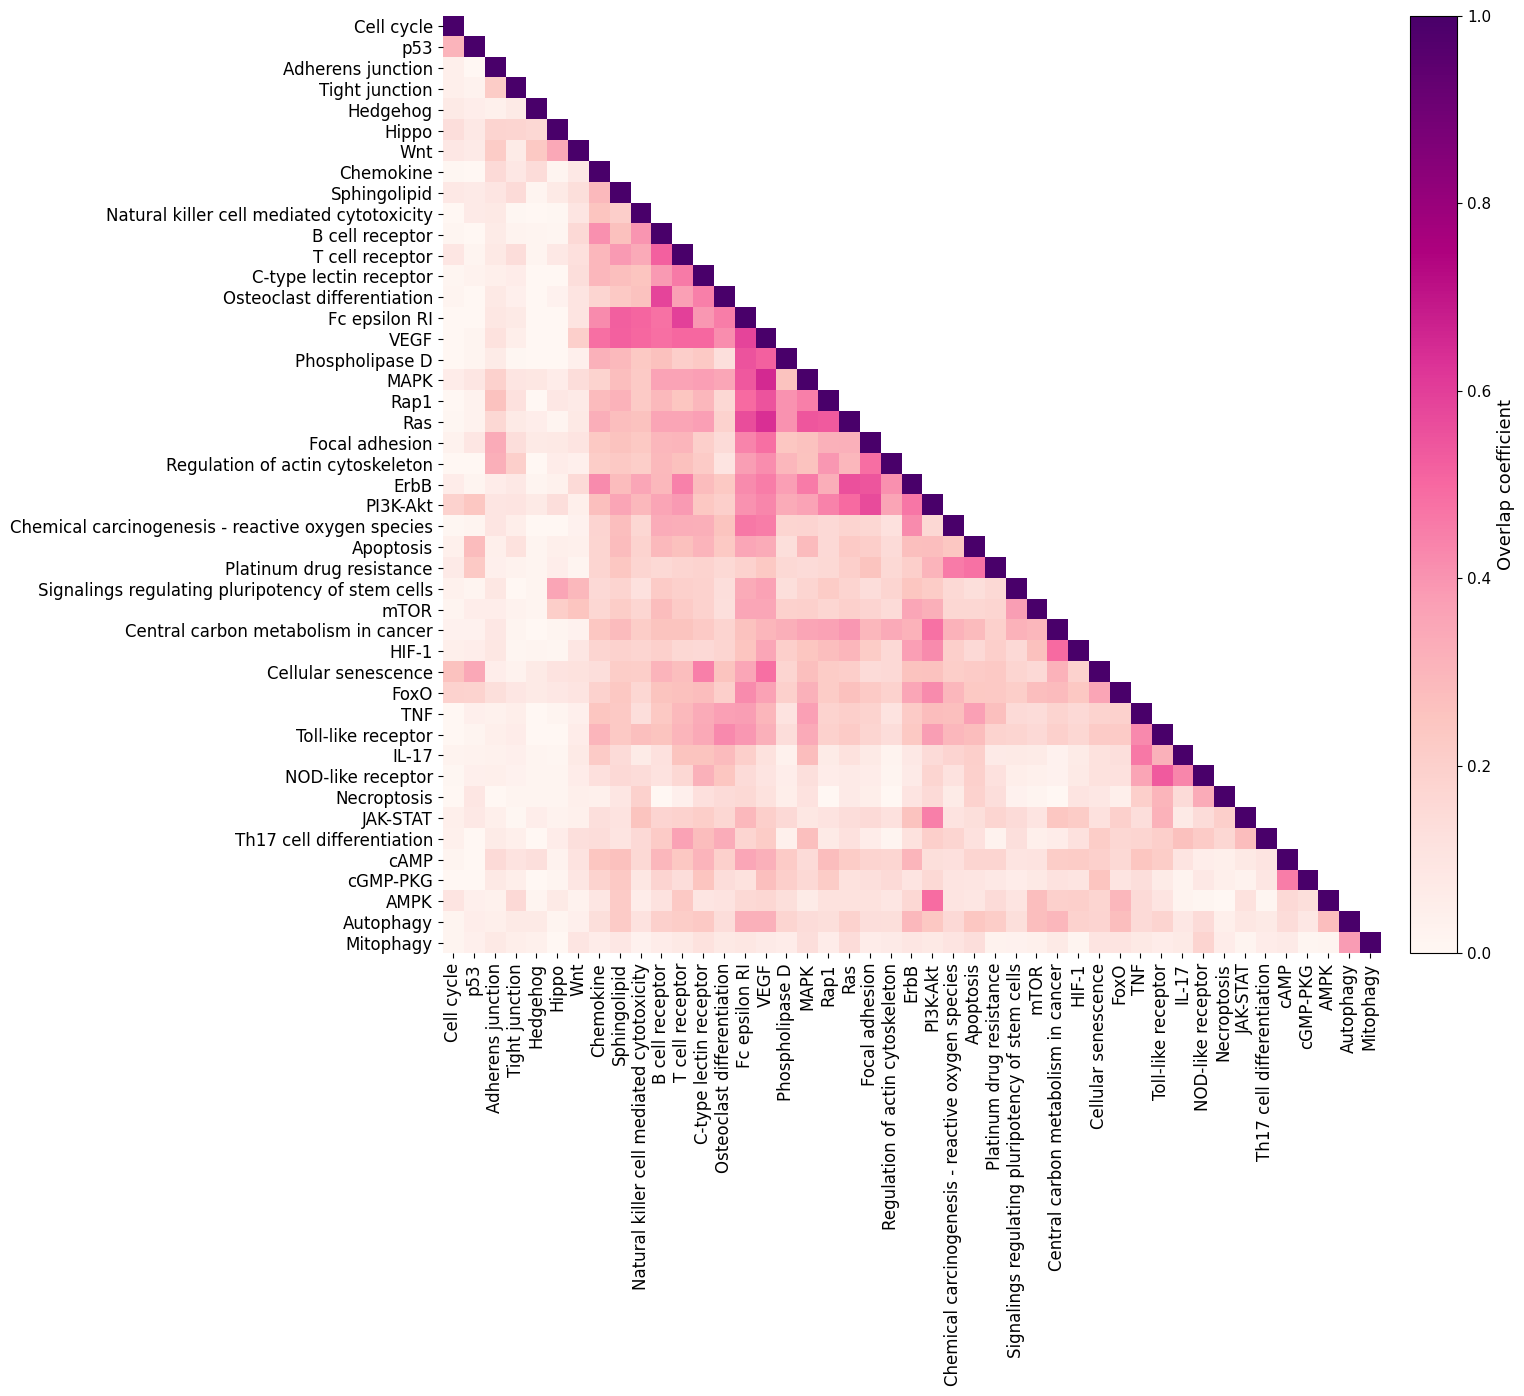

In [ ]:
# Build pathway gene sets restricted to enriched IDs
kegg_enr = kegg_u[kegg_u["Pathway_ID"].isin(enriched_ids)].copy()
kegg_enr["Pathway_Base"] = kegg_enr["Pathway_Name"].str.replace(r"\s*-\s*Homo\s+sapiens\s*\(human\)\s*$", "", regex=True)
pw_sets = kegg_enr.groupby("Pathway_Base")["HGNC"].apply(
    lambda s: set(s.dropna().unique()) - {"nan"}
)

# Overlap coefficient matrix
pws = pw_sets.index.tolist()
m = len(pws)
O = pd.DataFrame(np.eye(m), index=pws, columns=pws)

for i in range(m):
    for j in range(i + 1, m):
        inter = len(pw_sets.iloc[i] & pw_sets.iloc[j])
        denom = max(min(len(pw_sets.iloc[i]), len(pw_sets.iloc[j])), 1)
        O.iat[i, j] = O.iat[j, i] = inter / denom

overlap_thr = 0.75
O_filt = O.mask(np.eye(O.shape[0], dtype=bool)).where(lambda x: x <= overlap_thr)
keep = O_filt.notna().any(axis=1)
O = O.loc[keep, keep]

if O.shape[0] < 2:
    print(f"No pathway pairs with overlap coefficient >= {overlap_thr}")

else:
    # Shorten labels
    _clean = lambda s: (
        s.str.replace(r"\s*[–-]\s*Homo\s+sapiens.*$", "", regex=True)
         .str.replace(" signaling pathway", "", regex=False)
         .str.replace(" pathway", "", regex=False)
         .str.replace(" - animal", "", regex=False)
    )

    O.index = _clean(O.index.to_series())
    O.columns = O.index

    # Cluster & lower-triangle mask
    order = leaves_list(linkage(pdist(O.values, "euclidean"), "average"))
    Oord = O.iloc[order, order]

    tri = Oord.to_numpy(copy=True)
    tri[np.triu_indices_from(tri, k=1)] = np.nan
    Otri = pd.DataFrame(tri, index=Oord.index, columns=Oord.columns)

    # Plot
    fig, ax = plt.subplots(figsize=(18, 14))

    cmap = sns.color_palette("RdPu", as_cmap=True)
    cmap.set_bad((1, 1, 1, 0))

    im = ax.imshow(
        Otri.values,
        vmin=0,
        vmax=1,
        cmap=cmap,
        interpolation="nearest",
        aspect="equal"
    )

    ax.set_xticks(range(Otri.shape[1]))
    ax.set_yticks(range(Otri.shape[0]))

    ax.set_xticklabels(Otri.columns, rotation=90, ha="center", va="top", fontsize=12)
    ax.set_yticklabels(Otri.index, fontsize=12)

    for sp in ax.spines.values():
        sp.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Overlap coefficient", fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    plt.tight_layout()
    fig.savefig("../figs/supp_figs/Supplementary_Figure_S5.png", dpi=300, bbox_inches="tight")
    plt.show()

##### **2.3.- Compute pathway scores**

In [8]:
## Retrieve KEGG pathway scores
node_path = (nodeHGNC.merge(kegg[["HGNC", "Pathway_ID", "Pathway_Name"]], left_on = "HGNC_symbol", right_on = "HGNC", how = "inner")[["node_name", "Pathway_ID", "Pathway_Name"]])
id_cols = ["tissue", "cell_line", "perturbation"]
long_full = counts.melt(id_vars = id_cols, var_name = "node_name", value_name = "score")
long = long_full.merge(node_path, on = "node_name", how = "inner")
path_scores = (long.groupby(id_cols + ["Pathway_ID", "Pathway_Name"], as_index = False)["score"].median())
others = ["adrenal", "biliary", "prostate", "testis", "uterus", "vulva"]
path_scores["tissue"] = path_scores["tissue"].replace(others, "other")

# Select relevant pathways only
with open("/mnt/Datos/Project_VBP/paper/src/kegg_categories.json", "r") as f: 
    categories = json.load(f)
keep_ids = set().union(*[categories[k] for k in["metabolic_pathways_kegg", "environmental_information_processing_kegg", "cellular_processes_kegg", "organismal_systems_kegg"]])
path_scores = path_scores[path_scores["Pathway_ID"].isin(keep_ids)]
path_scores = path_scores[path_scores["Pathway_ID"].isin(enriched_ids)].reset_index(drop = True)
## Filter FNs and FPs
def make_pd_pair(a, b):
    a = a.astype(str)
    b = b.astype(str)
    return np.where(a <= b, a + "_" + b, b + "_" + a)

conf_mat = pd.read_csv("/mnt/Datos/Project_VBP/paper/src/conf_mat_vis.csv")

conf_mat["pd_combination"] = make_pd_pair(conf_mat["pd_combination"].str.split("-", expand=True)[0], conf_mat["pd_combination"].str.split("-", expand=True)[1])

keys = pd.MultiIndex.from_frame(conf_mat[["cell_line", "pd_combination"]])
main_idx = pd.MultiIndex.from_frame(path_scores[["cell_line", "perturbation"]])
mask = main_idx.isin(keys)
path_scores = path_scores[mask]

del counts

#### **3.- PCA of pathway level scores**

We restrict to double perturbations, pivot pathway scores into a sample × pathway matrix, standardize, and project onto two principal components. Points are colored by perturbation identity (combo overlay) and by tissue origin (per-combo grid).

In [9]:
def combo_to_drugs(combo, sep="+"):
    """PD_01_PD_08 → 'BCL2i+PI3Ki'"""
    parts = combo.split("_")
    ids = [f"{parts[i]}_{parts[i+1]}" for i in range(0, len(parts), 2)]
    return sep.join(drug_map.get(x, x) for x in ids)

# ── Shared PCA palette ──
PCA_COLORS = [
    "#0E3575","#2C61BF","#8AACED","#E89B0E","#F0C581",
    "#0B630B","#36C236","#ABDEAB","#DE313A","#EBABAF",
    "#7B11A8","#C5A9CC","#6E2035","#E0436D","#B59AA2",
    "#E629A1","#E8B7D7","#737373","#D6D6D6","#99935D",
    "#DEDCA4","#2D7D6D","#6ED4BE","#C7EDE5","#FCFF45",
]

def _style_ax(ax):
    """Common PCA axis styling."""
    ax.axhline(0, lw=0.6, c="k", alpha=0.2); ax.axvline(0, lw=0.6, c="k", alpha=0.2)
    ax.set_facecolor("#e5eaf7"); ax.set_axisbelow(True)
    ax.grid(True, color="white", linewidth=1)
    for s in ("top", "right"): ax.spines[s].set_visible(False)

##### **3.1.- Combo overlay (Figure 2A)**

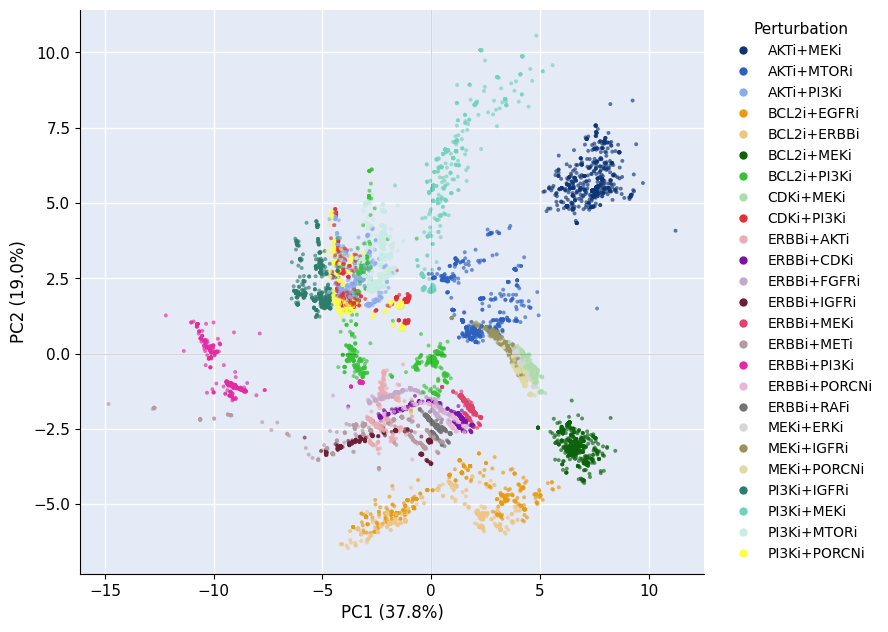

In [ ]:
# Filter to double perturbations & translate names
combos = path_scores[path_scores["perturbation"].str.contains("_PD_", regex=False)].copy()
combos["perturbation"] = combos["perturbation"].apply(combo_to_drugs)

# PCA
X = combos.pivot_table(index=["tissue", "cell_line", "perturbation"],
                        columns="Pathway_ID", values="score", fill_value=0)
pca = PCA(n_components=2)
PC = pca.fit_transform(StandardScaler().fit_transform(X))
pca_df = X.reset_index().assign(PC1=PC[:, 0], PC2=PC[:, 1])

combo_order = sorted(pca_df["perturbation"].unique())
combo2color = dict(zip(combo_order, PCA_COLORS))

# Plot
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=8, alpha=0.12, color="lightgrey", linewidths=0)
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=8, alpha=0.65,
           c=pca_df["perturbation"].map(combo2color), linewidths=0)
handles = [Line2D([], [], marker="o", ls="", ms=6, mfc=combo2color[c], mew=0)
           for c in combo_order]
ax.legend(handles, combo_order, title="Perturbation", bbox_to_anchor=(1.02, 1),
          loc="upper left", frameon=False, fontsize=10, title_fontsize=11)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.tick_params(labelsize=11)
_style_ax(ax)
plt.tight_layout()
fig.savefig("../figs/panels/Figure_2A.png", dpi=300, bbox_inches="tight")
plt.show()

##### **3.2.- Per combo tissue grid (Supplementary Figure S6)**

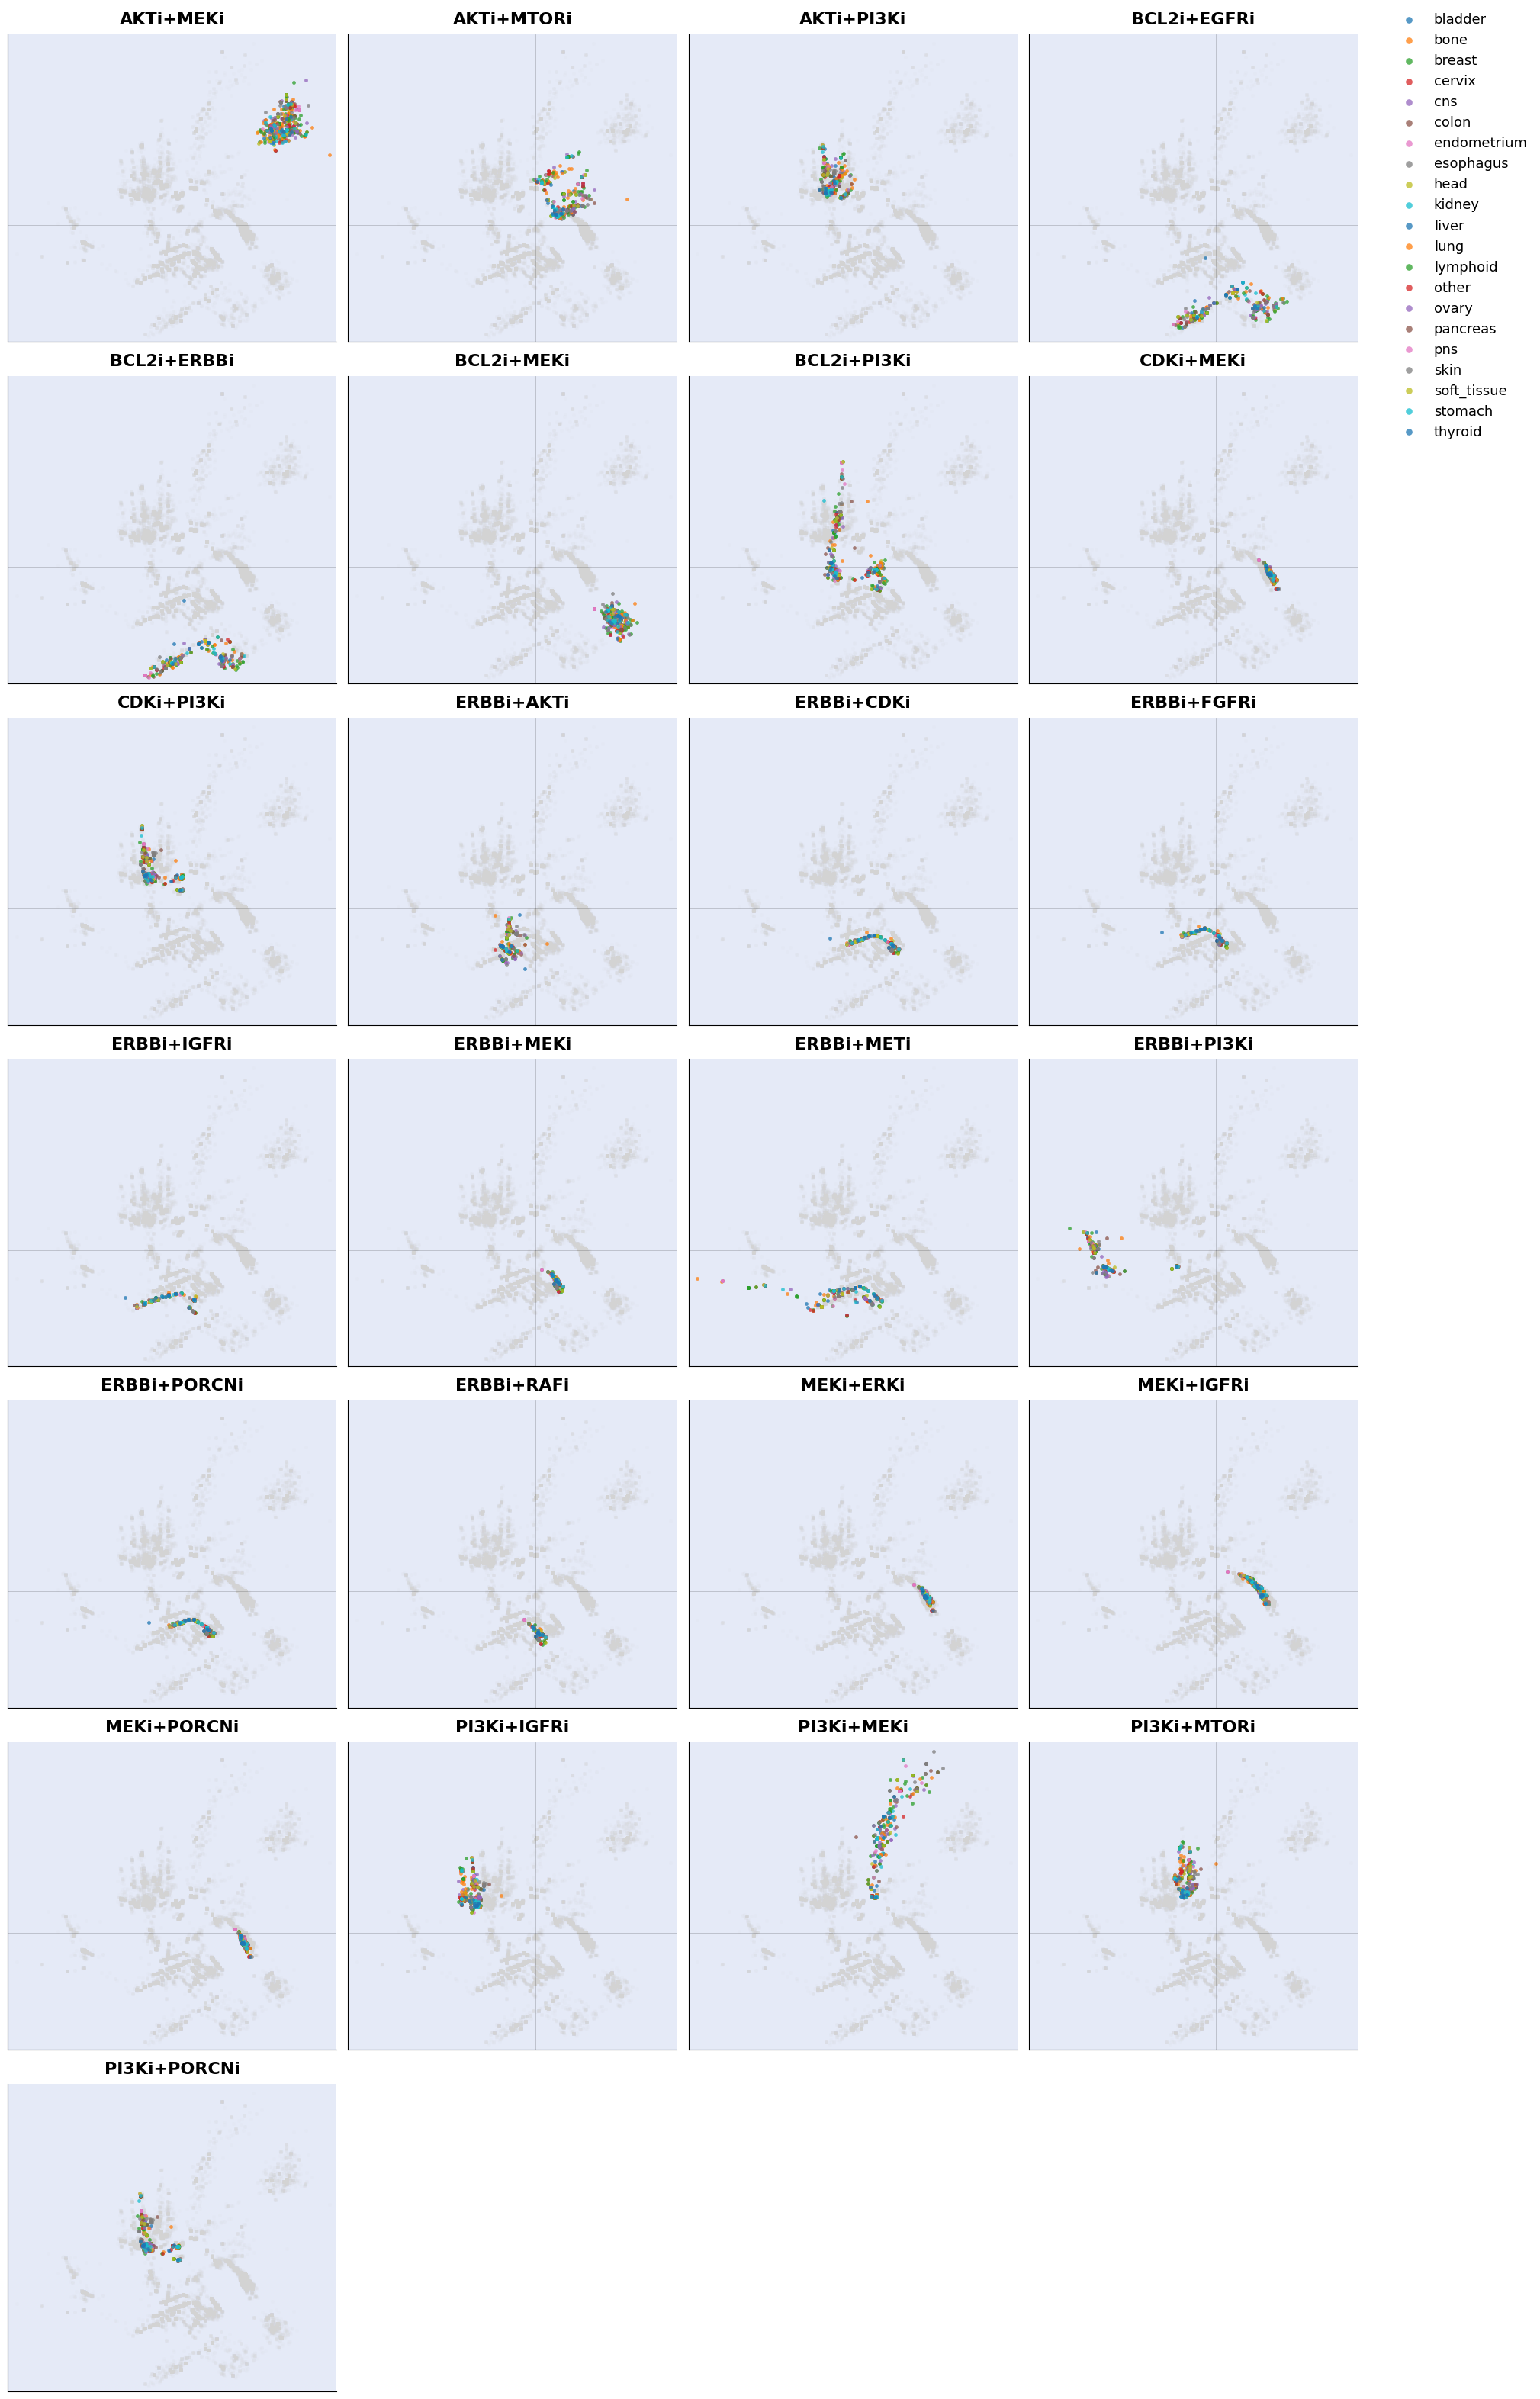

In [11]:
xlim = (pca_df["PC1"].min() * 1.05, pca_df["PC1"].max() * 1.05)
ylim = (pca_df["PC2"].min() * 1.05, pca_df["PC2"].max() * 1.05)
ncols = 4
nrows = int(np.ceil(len(combo_order) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes = np.array(axes).flatten()
for ax, combo in zip(axes, combo_order):
    ax.scatter(pca_df["PC1"], pca_df["PC2"], s=12, alpha=0.08, color="lightgrey", lw=0)
    for tissue, df_t in pca_df[pca_df["perturbation"] == combo].groupby("tissue"):
        ax.scatter(df_t["PC1"], df_t["PC2"], s=12, alpha=0.75, lw=0, label=tissue)
    ax.set_title(combo, fontsize=16, fontweight="bold", pad=10)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xticks([]); ax.set_yticks([])
    _style_ax(ax)
for ax in axes[len(combo_order):]:
    ax.set_visible(False)

h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, bbox_to_anchor=(1.01, 1), loc="upper left",
           frameon=False, fontsize=13, title_fontsize=14, markerscale=1.8)
plt.tight_layout()
fig.savefig("../figs/supp_figs/Supplementary_Figure_6.png", dpi=300, bbox_inches="tight")
plt.show()

##### **3.3.- Sensitivity analysis: pathway signatures in TP/TN/FP/FN (Figure 2B)**
Drug-combination pathway profiles were projected onto a per-combination axis separating true positive (TP) and true negative (TN) centroids. Pathway scores were standardized within each combination, projected onto the TP–TN axis, and normalized so that the TN centroid equals 0 and the TP centroid equals 1. The resulting TP-like pathway score quantifies how similar each response profile is to the TP pathway signature for the same drug combination. Scores were compared across confusion-matrix classes using a Kruskal–Wallis test, and pairwise rank-biserial correlations relative to TP are shown in the x-axis labels.

/tmp/ipykernel_120564/872364285.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_df, x="class", y="TP_like_score", order=order, showfliers=False, ax=ax, palette=["#e2540e", "#fbab6c", "#7798dc", "#4d67db"], linewidth=1.1, width=0.55)


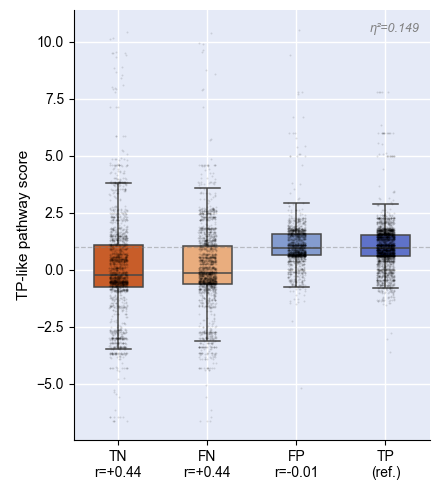

In [ ]:
conf_labels = conf_mat[["cell_line", "pd_combination", "confusion_matrix_value"]].rename(columns={"pd_combination": "perturbation", "confusion_matrix_value": "class"})
combos_cls = path_scores[path_scores["perturbation"].str.contains("_PD_", regex=False)].merge(conf_labels, on=["cell_line", "perturbation"], how="inner")
X_all = combos_cls.pivot_table(index=["tissue", "cell_line", "perturbation", "class"], columns="Pathway_ID", values="score", fill_value=0)

# Per-combo TP-like score (normalized: TN centroid → 0, TP centroid → 1)
rows = []
for pert, Xp in X_all.groupby(level="perturbation"):
    cp = Xp.index.get_level_values("class")
    if not {"True Positive", "True Negative"}.issubset(set(cp)): continue
    Xpz = pd.DataFrame(StandardScaler().fit_transform(Xp), index=Xp.index, columns=Xp.columns); cp = Xpz.index.get_level_values("class")
    tp_c, tn_c = Xpz[cp == "True Positive"].mean().values, Xpz[cp == "True Negative"].mean().values
    ax_vec = tp_c - tn_c; ax_vec /= np.linalg.norm(ax_vec)
    proj = Xpz.values @ ax_vec; tn0, tp1 = float(tn_c @ ax_vec), float(tp_c @ ax_vec)
    for cls_val, s in zip(cp, (proj - tn0) / (tp1 - tn0)): rows.append({"class": cls_val, "TP_like_score": float(s)})
dist_df = pd.DataFrame(rows)

order = ["True Negative", "False Negative", "False Positive", "True Positive"]
H, _ = kruskal(*[dist_df.loc[dist_df["class"] == c, "TP_like_score"].values for c in order])
eta2 = H / (len(dist_df) - 1)

def rb_r(a, b):
    x, y = dist_df.loc[dist_df["class"] == a, "TP_like_score"].values, dist_df.loc[dist_df["class"] == b, "TP_like_score"].values
    U, _ = mannwhitneyu(x, y, alternative="two-sided"); return 1 - 2 * U / (len(x) * len(y))

pairs_r = {(a, b): rb_r(a, b) for a, b in combinations(order, 2)}
r_tn = pairs_r[("True Negative", "True Positive")]
r_fn = pairs_r[("False Negative", "True Positive")]
r_fp = pairs_r[("False Positive", "True Positive")]

fig, ax = plt.subplots(figsize=(4.5, 5))
sns.boxplot(data=dist_df, x="class", y="TP_like_score", order=order, showfliers=False, ax=ax, palette=["#e2540e", "#fbab6c", "#7798dc", "#4d67db"], linewidth=1.1, width=0.55)
sns.stripplot(data=dist_df, x="class", y="TP_like_score", order=order, size=1.4, alpha=0.12, color="black", ax=ax)
ax.axhline(1, lw=0.9, ls="--", color="grey", alpha=0.45)
ax.set_xticks(range(4))
ax.set_xticklabels([f"TN\nr={r_tn:+.2f}", f"FN\nr={r_fn:+.2f}", f"FP\nr={r_fp:+.2f}", "TP\n(ref.)"], fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel(""); ax.set_ylabel("TP-like pathway score", fontsize=11)
ax.text(0.97, 0.97, f"η²={eta2:.3f}", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="grey", style="italic")
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("#e5eaf7")
ax.set_axisbelow(True)
ax.grid(True, color="white", linewidth=1)
plt.tight_layout()
fig.savefig("../figs/panels/Figure_2B.png", dpi=300, bbox_inches="tight")
plt.style.use("seaborn-v0_8-dark")
plt.show()



#### **4.- Clustered heatmaps**

Helper functions for pathway-level clustering and visualization. Most-variable pathways are retained, hierarchically clustered, and displayed as annotated heatmaps at the pan-cancer, tissue, and cell-line levels. The number of clusters is estimated via silhouette analysis.

##### **4.1.- Helper functions**

In [13]:
# ── Constants ──
SURVEY_CMAP = LinearSegmentedColormap.from_list("survey", ["#1f9fb5", "#ffffff", "#c0392b"], N=256)

PATHWAY_ABBREV = {
    "NOD-like receptor signaling pathway": "NOD-like rec.",
    "Hedgehog signaling pathway": "Hedgehog", "JAK-STAT signaling pathway": "JAK-STAT",
    "Mitophagy - animal": "Mitophagy", "Th17 cell differentiation": "Th17 diff.",
    "Hippo signaling pathway": "Hippo", "Wnt signaling pathway": "Wnt",
    "p53 signaling pathway": "p53", "MAPK signaling pathway": "MAPK",
    "IL-17 signaling pathway": "IL-17", "ErbB signaling pathway": "ErbB",
    "Ras signaling pathway": "Ras", "Fc epsilon RI signaling pathway": "FcεRI",
    "FoxO signaling pathway": "FoxO", "cGMP-PKG signaling pathway": "cGMP-PKG",
    "PI3K-Akt signaling pathway": "PI3K-Akt", "HIF-1 signaling pathway": "HIF-1",
    "Autophagy - animal": "Autophagy",
    "C-type lectin receptor signaling pathway": "C-type lectin rec.",
    "Toll-like receptor signaling pathway": "TLR",
    "T cell receptor signaling pathway": "TCR", "Osteoclast differentiation": "Osteoclast diff.",
    "TNF signaling pathway": "TNF", "cAMP signaling pathway": "cAMP",
    "Rap1 signaling pathway": "Rap1", "Sphingolipid signaling pathway": "Sphingolipid",
    "AMPK signaling pathway": "AMPK", "B cell receptor signaling pathway": "BCR",
    "Signaling pathways regulating pluripotency of stem cells": "Stem cell plurip.",
    "Phospholipase D signaling pathway": "PLD",
    "Natural killer cell mediated cytotoxicity": "NK cytotoxicity",
    "VEGF signaling pathway": "VEGF", "Chemokine signaling pathway": "Chemokine",
    "Cellular senescence": "Cell. senescence", "Regulation of actin cytoskeleton": "Actin cytoskel.",
    "mTOR signaling pathway": "mTOR", "NF-kappa B signaling pathway": "NF-κB",
    "Calcium signaling pathway": "Calcium", "Neurotrophin signaling pathway": "Neurotrophin",
    "RIG-I-like receptor signaling pathway": "RIG-I-like rec.",
    "Notch signaling pathway": "Notch", "TGF-beta signaling pathway": "TGF-β",
    "Prolactin signaling pathway": "Prolactin",
    "Phosphatidylinositol signaling system": "PI signaling",
    "Platelet activation": "Platelet activ.",
    "Fc gamma R-mediated phagocytosis": "FcγR phagocyt.",
}

DRUG_PATHWAY_COLORS = {
    "Apoptosis": "#8e6bbf", "RTK": "#4c9ed9", "AKT/MTOR": "#fdb462",
    "Cell cycle": "#4daf4a", "MAPK": "#fb8072", "WNT": "#bc80bd",
}

_BLACKLIST_COLS = {
    "Circadian rhythm", "Circadian entrainment", "Insulin secretion",
    "Glucagon signaling pathway", "Renin secretion",
    "Vasopressin-regulated water reabsorption",
    "Aldosterone synthesis and secretion", "Aldosterone-regulated sodium reabsorption",
    "Cortisol synthesis and secretion", "Thyroid hormone synthesis",
    "Parathyroid hormone synthesis, secretion and action",
    "Oxytocin signaling pathway", "Relaxin signaling pathway",
    "Ovarian steroidogenesis", "Progesterone-mediated oocyte maturation",
    "Oocyte meiosis", "GnRH secretion", "GnRH signaling pathway",
    "Estrogen signaling pathway", "Mealanogenesis", "Thermogenesis",
    "Metabolic pathways", "Hormone signaling", "Apoptosis - multiple species",
    "Longevity regulating pathway - multiple species",
    "Longevity regulation pathway - multiple species",
    "Dopaminergic synapse", "Serotonergic synapse", "Cholinergic synapse",
    "Long-term potentiation", "Long-term depression",
}


# ── Core helpers ──
def _split_combo_ids(s):
    parts = str(s).split("_")
    return [f"{parts[i]}_{parts[i+1]}" for i in range(0, len(parts), 2)]


def estimate_k(Xz, k_min=2, k_max=12):
    D = squareform(pdist(Xz.values, "euclidean"))
    Z = linkage(D, method="average")
    best_k, best_s = k_min, -np.inf
    for k in range(k_min, min(k_max, Xz.shape[0] - 1) + 1):
        lab = fcluster(Z, t=k, criterion="maxclust")
        if len(np.unique(lab)) < 2:
            continue
        s = silhouette_score(D, lab, metric="precomputed")
        if s > best_s:
            best_k, best_s = k, s
    return best_k, best_s


def make_Xz_and_K(path_scores, top_p=105, vlim=2.5, k_min=2, k_max=12,
                   tissue=False, cell_line=False):
    combos = path_scores[path_scores["perturbation"].str.contains("_PD_", regex=False)].copy()
    col_lab = "Pathway_Label" if "Pathway_Label" in combos.columns else "Pathway_Name"

    if cell_line:
        idx = ["perturbation", "tissue", "cell_line"] if tissue else ["perturbation", "cell_line"]
    elif tissue:
        combos = combos.groupby(["perturbation", "tissue", "Pathway_ID", col_lab],
                                as_index=False)["score"].median()
        idx = ["perturbation", "tissue"]
    else:
        combos = combos.groupby(["perturbation", "Pathway_ID", col_lab],
                                as_index=False)["score"].median()
        idx = ["perturbation"]

    X = combos.pivot_table(index=idx, columns=col_lab, values="score", fill_value=0)
    X = X[X.var().sort_values(ascending=False).head(top_p).index]
    Xz = pd.DataFrame(
        np.clip(StandardScaler().fit_transform(X), -vlim, vlim),
        index=X.index, columns=X.columns)
    Xz.columns = Xz.columns.str.replace(r"\s*[–-]\s*Homo\s+sapiens.*$", "", regex=True)
    Xz = Xz.drop(columns=[c for c in _BLACKLIST_COLS if c in Xz.columns])
    return Xz, *estimate_k(Xz, k_min, k_max)


def silcurve(Xz, kmin=2, kmax=12, save_path=None):
    D = squareform(pdist(Xz.values, "euclidean"))
    Z = linkage(D, method="average")
    Ks = list(range(kmin, kmax))
    sils = [silhouette_score(D, fcluster(Z, t=k, criterion="maxclust"), metric="precomputed")
            if len(np.unique(fcluster(Z, t=k, criterion="maxclust"))) >= 2 else np.nan
            for k in Ks]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(Ks, sils, marker="o", lw=2.5, ms=8, color="#4C40BD", alpha=0.6)
    ax.set_xlabel("Number of clusters (K)", fontsize=14)
    ax.set_ylabel("Silhouette score", fontsize=14)
    ax.tick_params(labelsize=12)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
def plot_cmap(Xz, K, figsize=(16, 6), vlim=2.5, y_fs=6, x_fs=8, row_gap=2,
              cluster_rows=True, cluster_cols=True, tissue_labels=None,
              row_split_labels=None, cluster_colors=None, pert_ids=None,
              show_rownames=True, show_colnames=True, label_fs=14, legend_fs=12,
              anno_fs=None, anno_w=8, subplot_gap=0.5, save_path=None, abbrev=True):
    """Annotated clustered heatmap via PyComplexHeatmap."""
    if abbrev:
        Xz = Xz.rename(columns=PATHWAY_ABBREV)
    if anno_fs is None:
        anno_fs = legend_fs
    plt.rcParams.update({"font.size": legend_fs, "legend.fontsize": legend_fs})

    # Cluster labels
    Z = linkage(pdist(Xz.values, "euclidean"), "average")
    labels = pd.Series(fcluster(Z, t=K, criterion="maxclust"), index=Xz.index).astype(str)
    split = row_split_labels if row_split_labels is not None else labels

    # Drug-pathway annotations
    p0 = pert_ids if pert_ids is not None else pd.Series(Xz.index.get_level_values(0), index=Xz.index)
    ids = p0.map(_split_combo_ids)
    pw1 = ids.map(lambda v: v[0] if v else None).map(drug_pathways).astype(str)
    pw2 = ids.map(lambda v: v[1] if len(v) > 1 else None).map(drug_pathways).astype(str)

    lkw = dict(color_text=False, labelcolor="black", fontsize=anno_fs)
    lbl_kw = dict(fontsize=anno_fs, color="black")
    annos = dict(
        Cluster=anno_simple(split, colors=cluster_colors, cmap=None if cluster_colors else "Set3",
                            height=anno_w, add_text=False, legend_kws=lkw),
        Drug1=anno_simple(pw1, colors=DRUG_PATHWAY_COLORS, height=anno_w, add_text=False, legend_kws=lkw),
        Drug2=anno_simple(pw2, colors=DRUG_PATHWAY_COLORS, height=anno_w, add_text=False, legend_kws=lkw),
    )
    if tissue_labels is not None:
        annos = {k: v for k, v in [
            ("Cluster", annos["Cluster"]),
            ("Tissue", anno_simple(tissue_labels, height=anno_w, add_text=False, legend_kws=lkw)),
            ("Drug1", annos["Drug1"]), ("Drug2", annos["Drug2"]),
        ]}
    left_ha = HeatmapAnnotation(**annos, axis=0, verbose=0, plot_legend=True,
                                 legend_gap=15, label_side="bottom", label_kws=lbl_kw)

    plt.figure(figsize=figsize)
    cm = ClusterMapPlotter(
        data=Xz, cmap=SURVEY_CMAP, center=0, vmin=-vlim, vmax=vlim,
        row_cluster=cluster_rows, col_cluster=cluster_cols,
        row_cluster_method="average", row_cluster_metric="euclidean",
        row_split=split if (row_split_labels is not None or cluster_rows) else None,
        row_split_gap=row_gap, left_annotation=left_ha,
        row_dendrogram=cluster_rows, col_dendrogram=cluster_cols,
        show_rownames=show_rownames, show_colnames=show_colnames, row_names_side="right",
        xticklabels_kws=dict(labelrotation=90, labelsize=x_fs),
        yticklabels_kws=dict(labelsize=y_fs),
        legend_hpad=100, legend_vpad=30, subplot_gap=subplot_gap,
        legend_width=120, legend_gap=30, verbose=0, plot=True, label="heatmap",
    )

    # Force all legend text to black
    import matplotlib.legend as _ml
    for ax in plt.gcf().get_axes():
        for child in ax.get_children():
            if isinstance(child, _ml.Legend):
                child.get_title().set_color("black")
                child.get_title().set_fontsize(anno_fs)
                for t in child.get_texts():
                    t.set_color("black"); t.set_fontsize(anno_fs)
    if save_path:
        plt.gcf().savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return cm, labels

##### **4.2.- Pan-cancer heatmap**

In [15]:
### Filter out FPs and FNs
path_scores = path_scores[pd.MultiIndex.from_frame(path_scores[["cell_line", "perturbation"]]).isin(pd.MultiIndex.from_frame(conf_mat.loc[conf_mat["confusion_matrix_value"].isin(["True Positive", "True Negative"]), ["cell_line", "pd_combination"]]))].copy()

/tmp/ipykernel_120564/887050615.py:68: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")
/tmp/ipykernel_120564/887050615.py:68: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")


K_auto = 2  sil = 0.384
K (w/o AKTi+MEKi) = 8  sil = 0.369


/home/marco/.local/lib/python3.11/site-packages/PyComplexHeatmap/annotations.py:229: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.plot_data.fillna(np.nan, inplace=True)
/home/marco/.local/lib/python3.11/site-packages/PyComplexHeatmap/annotations.py:229: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.plot_data.fillna(np.nan, inplace=True)
/home/marco/.local/lib/python3.11/site-packages/PyComplexHeatmap/annotations.py:229: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. 

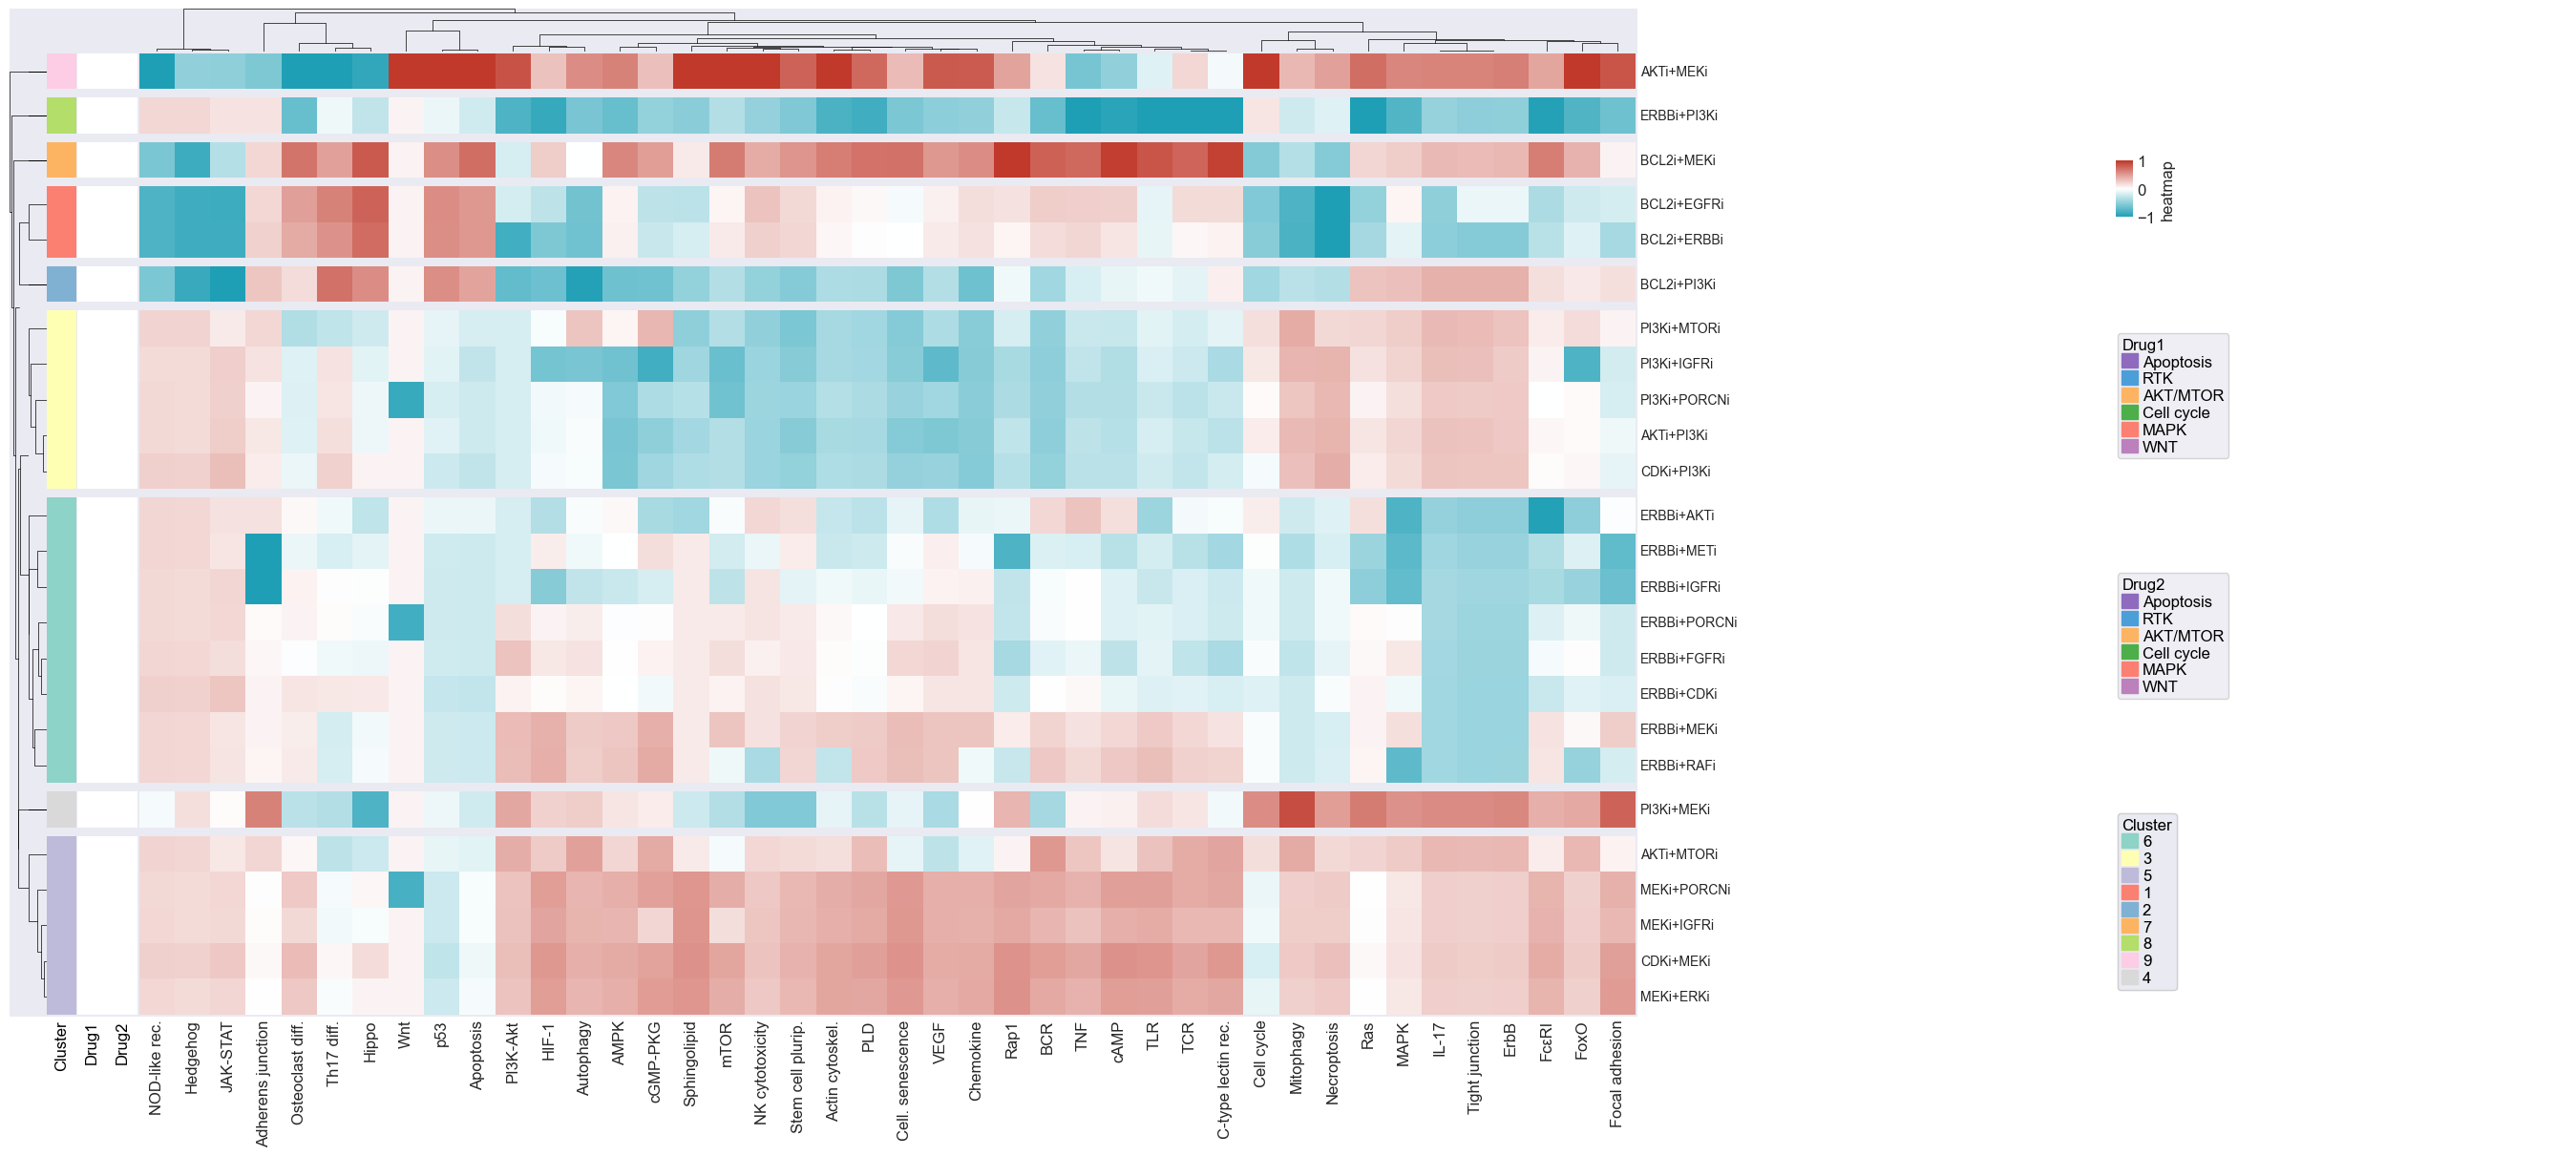

In [16]:
Xz, K_auto, sil = make_Xz_and_K(path_scores, top_p=1000)
pert_ids = pd.Series(Xz.index, index=Xz.index)
Xz.index = Xz.index.map(combo_to_drugs)
print(f"K_auto = {K_auto}  sil = {sil:.3f}")

# Remove AKTi+MEKi outlier, re-estimate K, then re-insert as separate split
out = "AKTi+MEKi"
Xz_no = Xz.drop(out)
K_auto_no, sil_no = estimate_k(Xz_no)
print(f"K (w/o {out}) = {K_auto_no}  sil = {sil_no:.3f}")

Z_no = linkage(pdist(Xz_no.values, "euclidean"), "average")
labels_no = pd.Series(fcluster(Z_no, t=K_auto_no, criterion="maxclust"),
                       index=Xz_no.index).astype(str)
row_split = labels_no.reindex(Xz.index)
row_split.loc[out] = str(K_auto_no + 1)

cmap_pc, labels = plot_cmap(
    Xz, K_auto_no, figsize=(22, 12), pert_ids=pert_ids,
    row_split_labels=row_split, y_fs=10, x_fs=12, label_fs=14)

##### **4.3.- Tissue-level heatmap (Figure 2C)**

/tmp/ipykernel_120564/887050615.py:68: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")
/tmp/ipykernel_120564/887050615.py:108: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")


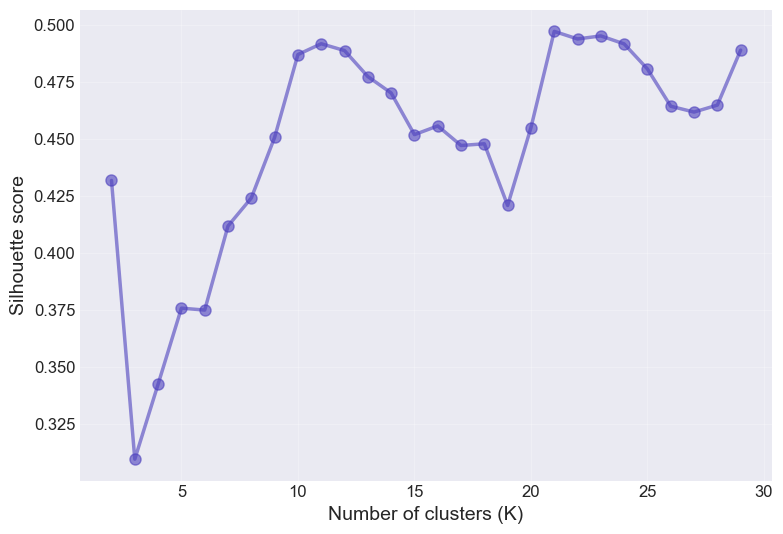

K = 10  sil = 0.497
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


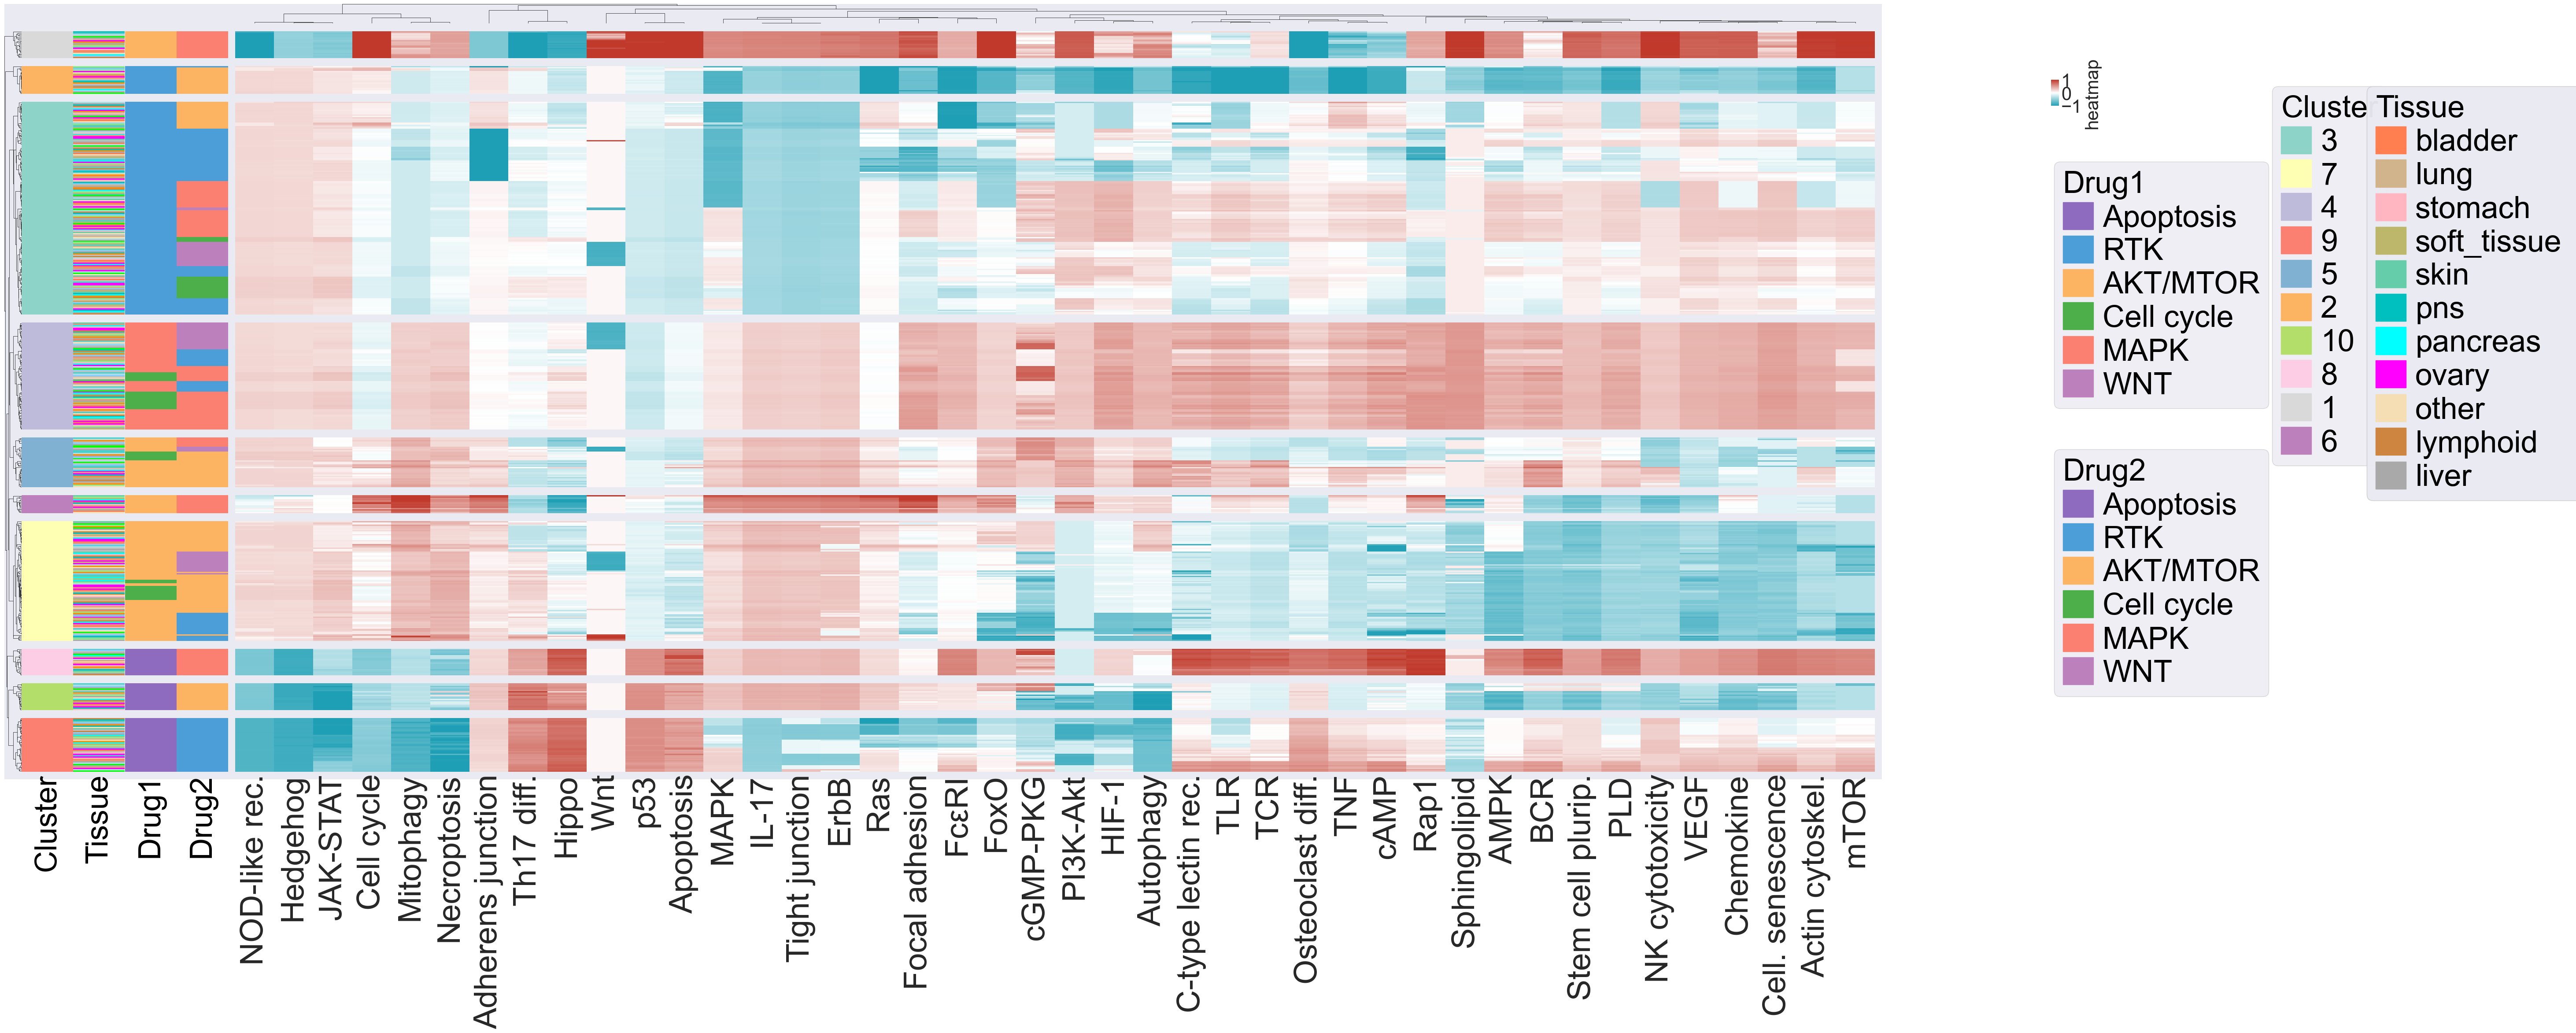

In [ ]:
Xz_t, K_auto_t, sil_t = make_Xz_and_K(path_scores, k_min=2, k_max=30, tissue=True)
silcurve(Xz_t, kmin=2, kmax=30)

K_auto_t = 10  # override after visual inspection
print(f"K = {K_auto_t}  sil = {sil_t:.3f}")

labels_t = pd.Series(
    fcluster(linkage(pdist(Xz_t.values, "euclidean"), "average"),
             t=K_auto_t, criterion="maxclust"),
    index=Xz_t.index).astype(str)
pert_ids_t = pd.Series(Xz_t.index.get_level_values(0), index=Xz_t.index)
tissue_labels = pd.Series(Xz_t.index.get_level_values(1), index=Xz_t.index).astype(str)

cmap_t, _ = plot_cmap(
    Xz_t, K_auto_t, cluster_rows=True, cluster_cols=True,
    tissue_labels=tissue_labels, row_split_labels=labels_t,
    figsize=(55, 20), pert_ids=pert_ids_t, show_rownames=False,
    row_gap=4, y_fs=18, x_fs=52, label_fs=6,
    legend_fs=30, anno_fs=50, anno_w=30, subplot_gap=4,
    save_path="../figs/panels/Figure_2C.png")

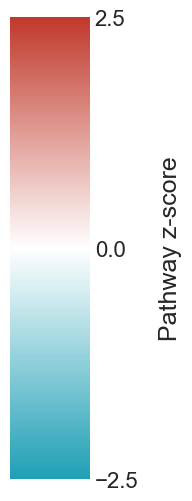

/tmp/ipykernel_120564/3909291336.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


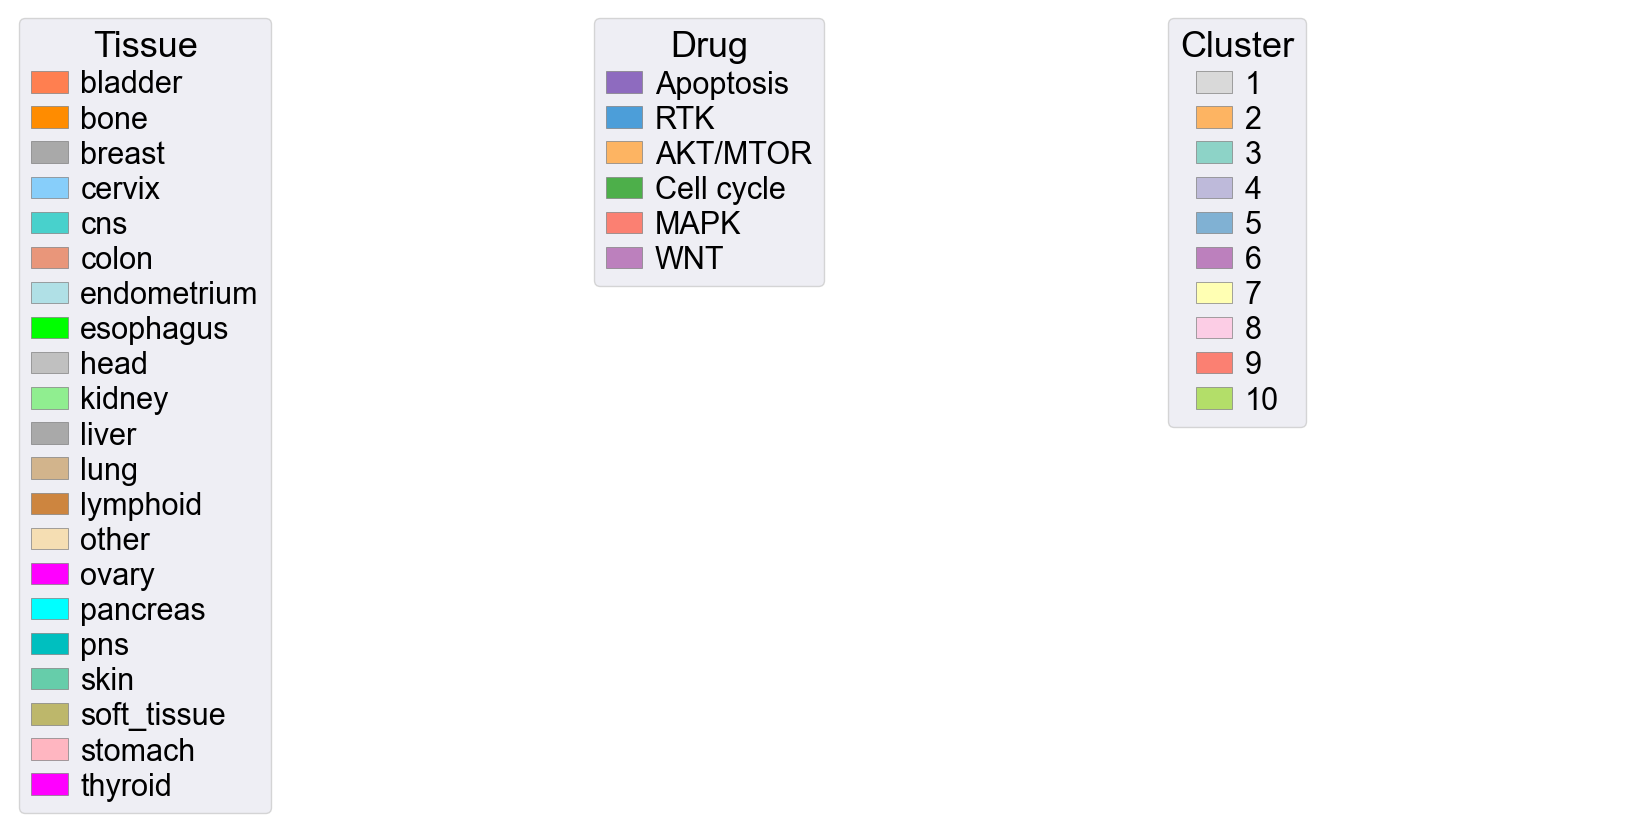

In [20]:
# Standalone colorbar
fig, ax = plt.subplots(figsize=(2, 6))
fig.subplots_adjust(left=0.5)
norm = Normalize(vmin=-2.5, vmax=2.5)
sm = plt.cm.ScalarMappable(cmap=SURVEY_CMAP, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, cax=ax, orientation="vertical")
cbar.set_label("Pathway z-score", fontsize=18, labelpad=15)
cbar.ax.tick_params(labelsize=16); cbar.set_ticks([-2.5, 0, 2.5])
plt.savefig("../figs/panels/Figure_3B_colorbar.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# Standalone annotation legends
anno_colors = {a.label: a.color_dict for a in cmap_t.left_annotation.annotations}
legend_groups = {
    "Tissue":  sorted(anno_colors["Tissue"]),
    "Drug":    list(anno_colors["Drug1"]),
    "Cluster": sorted(anno_colors["Cluster"], key=lambda x: int(x)),
}
fs, tfs = 22, 26
fig, axes = plt.subplots(1, 3, figsize=(21, 4))
for ax, (title, keys) in zip(axes, legend_groups.items()):
    ax.axis("off")
    cdict = anno_colors.get(title, anno_colors.get("Drug1"))
    handles = [Patch(facecolor=cdict[k], edgecolor="grey", lw=0.5, label=k) for k in keys]
    leg = ax.legend(handles=handles, title=title, loc="upper left", frameon=True,
                    fontsize=fs, title_fontsize=tfs, labelcolor="black",
                    handlelength=1.2, handletextpad=0.4, borderpad=0.4,
                    labelspacing=0.2, borderaxespad=0.3)
    leg.get_title().set_color("black")
plt.tight_layout()
plt.savefig("../figs/panels/Figure_3B_legends.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

##### **4.4.- Cell-line-level heatmap**

/tmp/ipykernel_120564/887050615.py:68: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")
/tmp/ipykernel_120564/887050615.py:108: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")


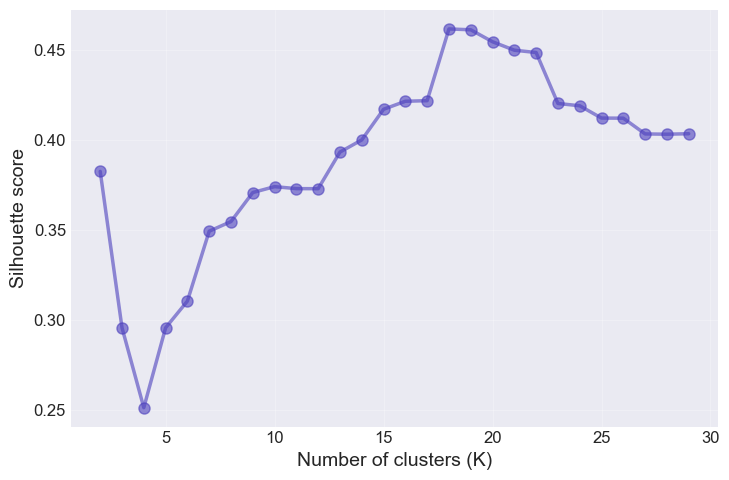

Incresing ncol
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


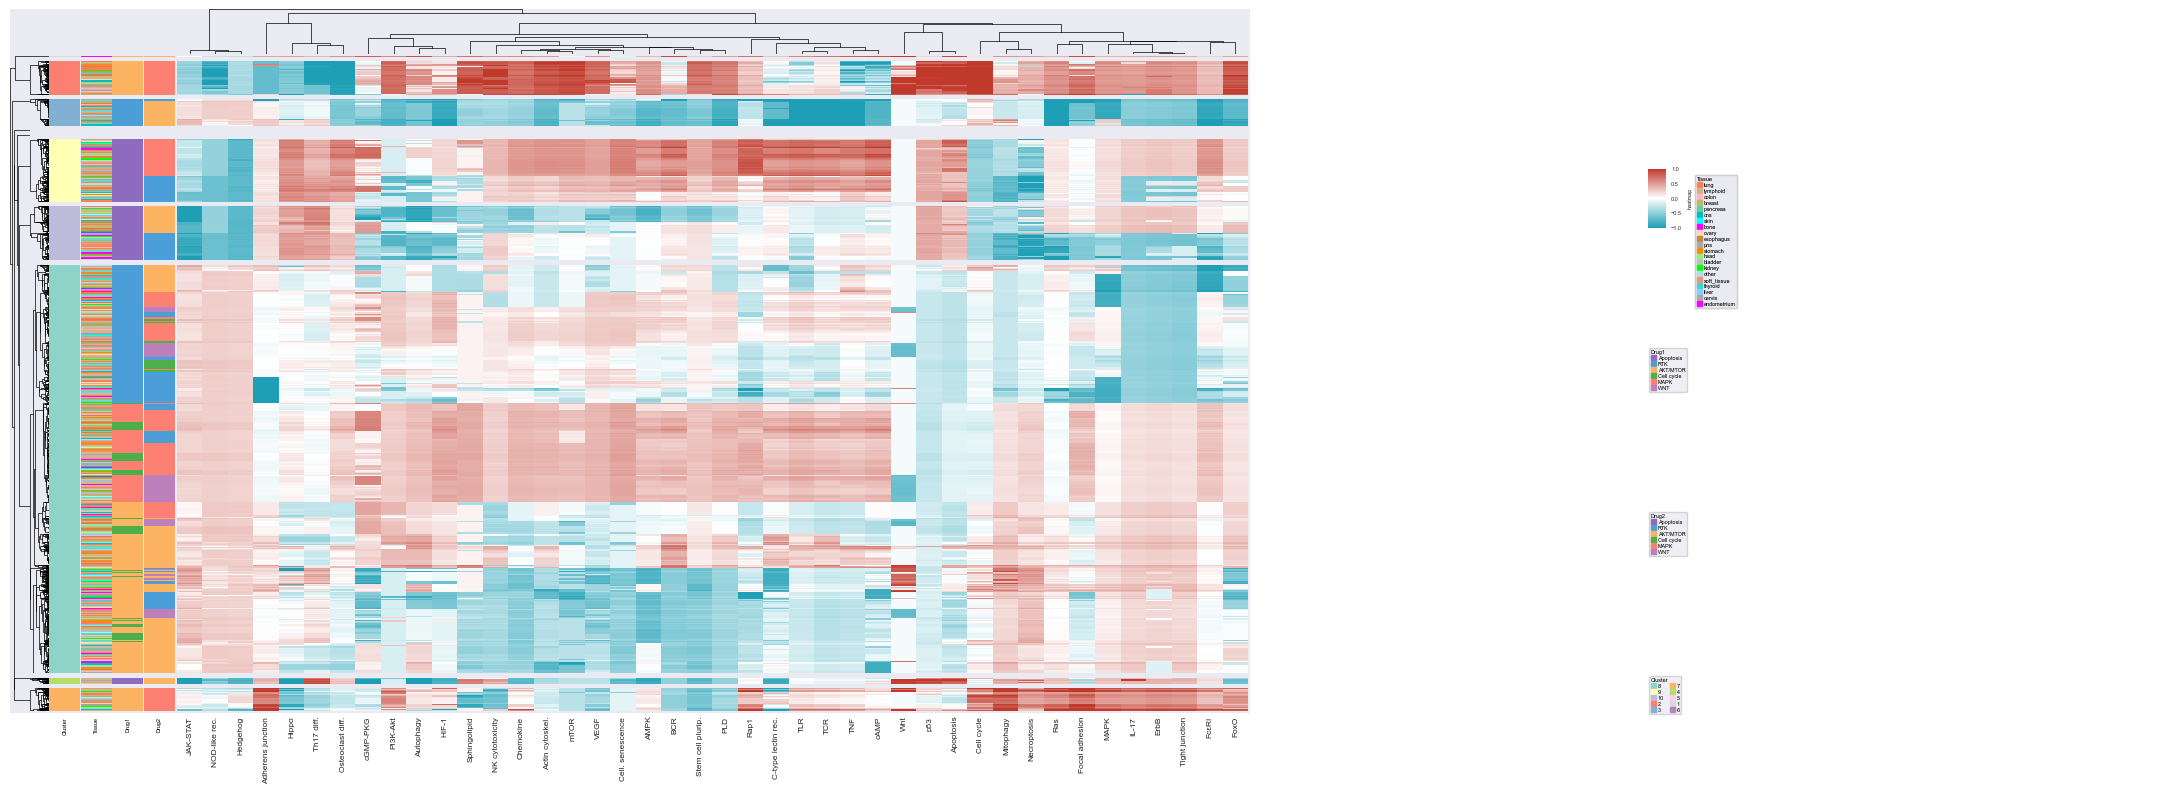

In [21]:
# --- build matrix & choose k ------------------------------------------------
Xz_cl, K_auto_cl, sil_cl = make_Xz_and_K(
    path_scores, top_p=150,
    tissue=True, cell_line=True, k_min=2, k_max=20,
)
silcurve(Xz_cl, 2, 30)

# --- cluster ----------------------------------------------------------------
Z_cl = linkage(pdist(Xz_cl.values, metric="euclidean"), method="average")
labels_cl = pd.Series(
    fcluster(Z_cl, t=10, criterion="maxclust"), index=Xz_cl.index
).astype(str)

pert_ids_cl = pd.Series(Xz_cl.index.get_level_values(0), index=Xz_cl.index)
tissue_cl   = pd.Series(Xz_cl.index.get_level_values(1), index=Xz_cl.index).astype(str)

# --- plot -------------------------------------------------------------------
cmap_cl, _ = plot_cmap(
    Xz_cl, 10,
    cluster_rows=True, cluster_cols=True,
    tissue_labels=tissue_cl, row_split_labels=labels_cl,
    pert_ids=pert_ids_cl, show_rownames=False,
    figsize=(16, 8), y_fs=4, x_fs=6, legend_fs=4, row_gap=1,
)

##### **4.5.- Cluster composition - Sankey diagram (Figure 3A)**

In [ ]:
CLUSTER_COLORS = {
    "1": "#D6D6D6", "2": "#FFBA4D", "3": "#8DEBCA", "4": "#C4B6D1",
    "5": "#80b1d3", "6": "#B368A0", "7": "#F7F6A1", "8": "#F2C2E7",
    "9": "#E66C6C", "10": "#A3E66C",
}

def _hex_to_rgba(h, alpha=0.55):
    h = h.lstrip("#")
    return f"rgba({int(h[:2],16)},{int(h[2:4],16)},{int(h[4:6],16)},{alpha})"

# --- build percent table ----------------------------------------------------
THR_PCT = 1.0
pct = (
    labels_t.rename("cluster").reset_index()
    .groupby(["cluster", "perturbation"]).size()
    .rename("count").reset_index()
    .assign(percent=lambda d: d["count"] / d.groupby("cluster")["count"].transform("sum") * 100)
)
pct["pert_plot"] = (
    pct.apply(lambda r: r["perturbation"] if r["percent"] >= THR_PCT else "Other", axis=1)
    .apply(combo_to_drugs)
)
pct = (
    pct.groupby(["cluster", "pert_plot"], as_index=False)["percent"].sum()
    .sort_values(["cluster", "pert_plot"], key=lambda s: s.astype(int) if s.name == "cluster" else s)
    .reset_index(drop=True)
)

# --- Sankey node / link setup ------------------------------------------------
clusters = [f"Cluster {c}" for c in sorted(pct["cluster"].astype(int).unique())]
perts = pct["pert_plot"].unique().tolist()
nodes = clusters + perts
node2i = {n: i for i, n in enumerate(nodes)}

source = [node2i[f"Cluster {c}"] for c in pct["cluster"]]
target = [node2i[p] for p in pct["pert_plot"]]
values = pct["percent"].tolist()

node_colors = [
    CLUSTER_COLORS.get(n.split()[-1], "#CCCCCC") if n.startswith("Cluster") else "#E0E0E0"
    for n in nodes
]
link_colors = [_hex_to_rgba(CLUSTER_COLORS.get(str(c), "#999999")) for c in pct["cluster"]]

# --- plot --------------------------------------------------------------------
fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=[f"<b>{n}</b>" for n in nodes],
        pad=20, thickness=24, color=node_colors,
        line=dict(color="white", width=0.5),
    ),
    link=dict(
        source=source, target=target, value=values,
        color=link_colors, label=[f"{v:.1f}%" for v in values],
    ),
))
fig.update_layout(
    width=900, height=1400,
    font=dict(size=24, family="Arial"),
    margin=dict(l=20, r=20, t=30, b=20),
)
fig.write_image("../figs/panels/Figure_3A.png", scale=3)
fig.show()

INFO Chromium init'ed with kwargs {}
INFO Found chromium path: /bin/google-chrome
INFO Temp directory created: /tmp/tmpc6l8nmhi.
INFO Opening browser.
INFO Temp directory created: /tmp/tmp4xj55ruz.
INFO ldd failed. e: Command '['ldd', '/bin/google-chrome']' returned non-zero exit status 1., stderr: None
INFO Temporary directory at: /tmp/tmp4xj55ruz
INFO Conforming 1 to file:///tmp/tmpc6l8nmhi/index.html
INFO Waiting on all navigates
INFO All navigates done, putting them all in queue.
INFO Getting tab from queue (has 1)
INFO Got 59D5
INFO Processing fig.png
INFO Sending big command for fig.png.
INFO Sent big command for fig.png.
INFO Reloading tab 59D5 before return.
INFO Putting tab 59D5 back (queue size: 0).
INFO Waiting for all cleanups to finish.
INFO Exiting Kaleido
INFO Closing browser.
INFO Closing browser.
INFO TemporaryDirectory.cleanup() worked.
INFO shutil.rmtree worked.
INFO Cancelling tasks.
INFO Exiting Kaleido/Choreo
INFO TemporaryDirectory.cleanup() worked.
INFO shutil.r

##### **4.6.- Cluster composition - dotplot (Figure 3B)**

While neither tissue- nor cell-line-specific clustering patterns emerged,
incorporating tissue-level stratification yielded a slight but reproducible gain
in resolution compared to the pan-cancer setting.  We therefore adopted
tissue-level resolution to explore cluster-specific pathway signatures.

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical un

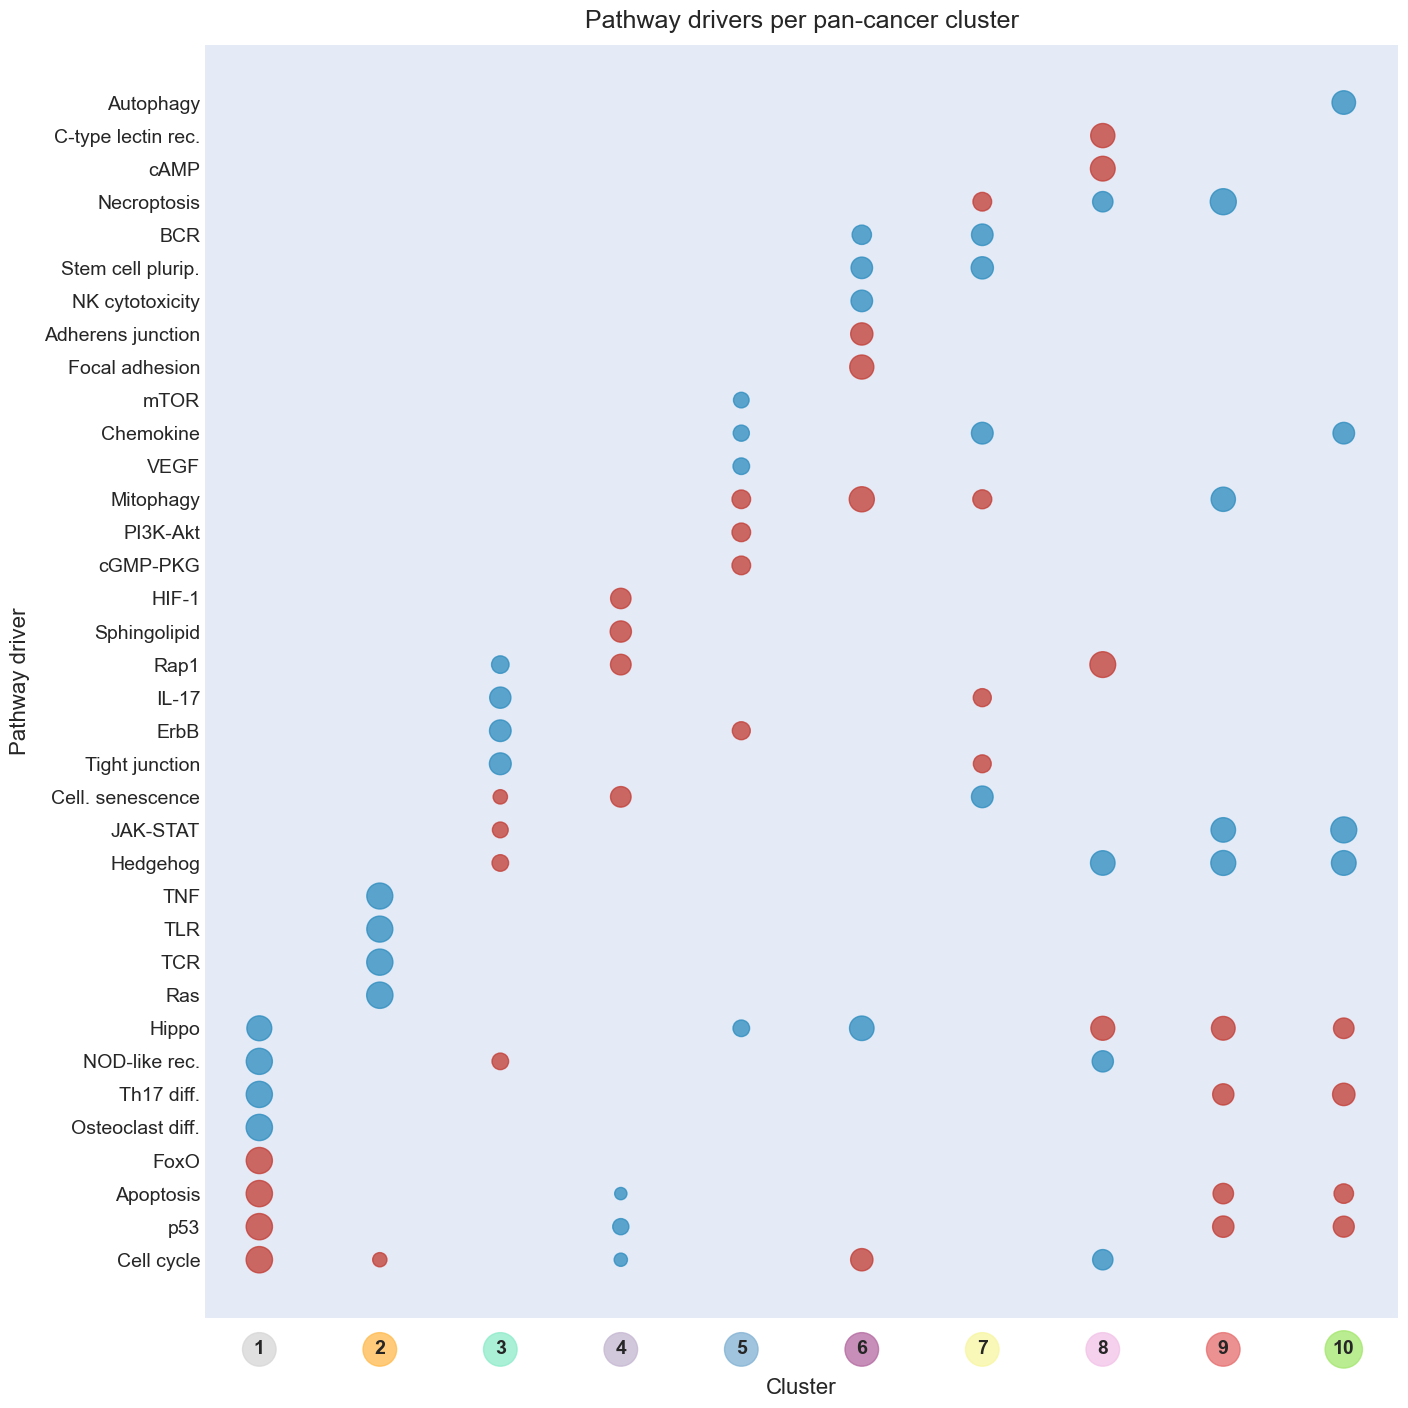

In [ ]:
def cluster_drivers(data, labels, alpha=0.01, top_n=20, min_cons=0.65):
    """Wilcoxon rank-sum test per cluster vs. rest, FDR-corrected."""
    labels = pd.Series(labels, index=data.index).astype(str)
    out = {}
    for cl in sorted(labels.unique(), key=lambda x: int(x) if x.isdigit() else x):
        mask = labels == cl
        Xin, Xout = data.loc[mask], data.loc[~mask]
        pvals = pd.Series(
            [ranksums(Xin[c], Xout[c]).pvalue for c in data.columns],
            index=data.columns,
        )
        _, qvals, _, _ = multipletests(pvals, method="fdr_bh")
        delta = Xin.mean() - Xout.mean()
        cons_up = (Xin > 0).mean()
        cons_dn = (Xin < 0).mean()
        df = pd.DataFrame({
            "delta": delta, "qval": qvals,
            "cons_up": cons_up, "cons_dn": cons_dn,
            "n_in": mask.sum(), "n_out": (~mask).sum(),
        })
        sig_up = df[(df.delta > 0) & (df.qval < alpha) & (df.cons_up >= min_cons)]
        sig_dn = df[(df.delta < 0) & (df.qval < alpha) & (df.cons_dn >= min_cons)]
        out[cl] = {
            "up":   sig_up.nlargest(top_n, "delta"),
            "down": sig_dn.nsmallest(top_n, "delta"),
        }
    return out


def build_dotplot(drivers, top_n=4):
    """Select top_n up/down per cluster and return a tidy DataFrame."""
    rows = []
    for cl, d in drivers.items():
        for pw, r in d["up"].nlargest(top_n, "delta").iterrows():
            rows.append({"cluster": str(cl), "pathway": pw, "delta": r["delta"]})
        for pw, r in d["down"].nsmallest(top_n, "delta").iterrows():
            rows.append({"cluster": str(cl), "pathway": pw, "delta": r["delta"]})
    return pd.DataFrame(rows)


def plot_drivers(df, figsize=(14, 14), fontsize=14, save_path=None):
    """Dot plot of pathway drivers per cluster."""
    df = df.copy()
    df["pathway"] = df["pathway"].replace(PATHWAY_ABBREV)

    colors = df["delta"].apply(lambda d: "#c23b32" if d > 0 else "#2b8cbe")
    sizes = df["delta"].abs()
    sizes = sizes / sizes.max() * 300 + 60

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#e5eaf7"); ax.set_axisbelow(True)
    ax.scatter(df["cluster"], df["pathway"], s=sizes, c=colors,
               alpha=0.75, edgecolors=colors, linewidths=1)
    ax.set_xlabel("Cluster", fontsize=fontsize + 2, labelpad=40)
    ax.set_ylabel("Pathway driver", fontsize=fontsize + 2, labelpad=10)
    ax.set_title("Pathway drivers per pan-cancer cluster",
                 fontsize=fontsize + 4, pad=12)
    ax.tick_params(axis="both", labelsize=fontsize)

    # Coloured cluster badges on x-axis
    ax.set_xticklabels([])
    ylo, yhi = ax.get_ylim()
    y_pos = ylo - 0.025 * (yhi - ylo)
    for cl in sorted(df["cluster"].unique(), key=int):
        ax.text(
            cl, y_pos, cl, ha="center", va="center",
            fontsize=fontsize, fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.4",
                      facecolor=CLUSTER_COLORS.get(cl, "#ddd"),
                      edgecolor=CLUSTER_COLORS.get(cl, "#ddd"),
                      linewidth=1, alpha=0.75),
            clip_on=False,
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# --- run ---------------------------------------------------------------------
drivers_t = cluster_drivers(Xz_t, labels_t)
dot_df = build_dotplot(drivers_t, top_n=4)
plot_drivers(dot_df, save_path="../figs/panels/Figure_3B.png")

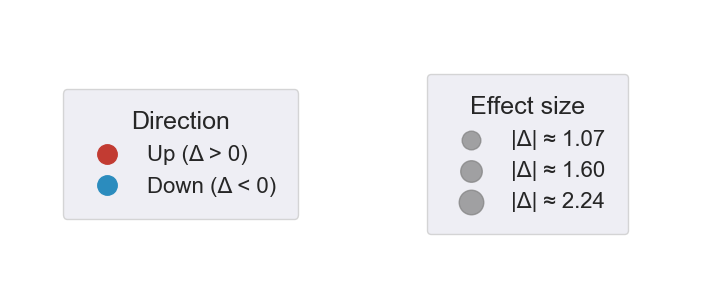

In [24]:
# Standalone legends for Figure 4B
sizes_raw = dot_df["delta"].abs()
sizes_scaled = sizes_raw / sizes_raw.max() * 300 + 60
size_vals = np.quantile(sizes_scaled, [0.25, 0.5, 0.75])
delta_vals = np.quantile(sizes_raw, [0.25, 0.5, 0.75])

fs = 20
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Direction
ax1.axis("off")
ax1.legend(
    handles=[
        Line2D([], [], marker="o", ls="", mfc="#c23b32", mec="#c23b32", ms=fs - 6, label="Up (Δ > 0)"),
        Line2D([], [], marker="o", ls="", mfc="#2b8cbe", mec="#2b8cbe", ms=fs - 6, label="Down (Δ < 0)"),
    ],
    title="Direction", frameon=True, loc="center",
    fontsize=fs - 4, title_fontsize=fs - 2, borderpad=1,
)

# Effect size
ax2.axis("off")
ax2.legend(
    handles=[ax2.scatter([], [], s=s, color="grey", alpha=0.7) for s in size_vals],
    labels=[f"|Δ| ≈ {v:.2f}" for v in delta_vals],
    title="Effect size", frameon=True, loc="center",
    fontsize=fs - 4, title_fontsize=fs - 2, borderpad=1,
)

plt.tight_layout()
plt.savefig("../figs/panels/Figure_4B_legend.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

##### **4.7.- Within-combination functional heterogeneity in PI3K-MEK co-inhibition (Supplementary Figure S7)**

This analysis compares pathway-level response profiles between clusters 5 and 6 within the PI3Ki+MEKi drug-combination group. The analysis is restricted to samples assigned to the target combination and belonging to either cluster 5 or cluster 6. For each pathway, median standardized pathway scores are computed in both clusters, and the difference between clusters is quantified as Δ median z-score, defined as cluster 6 minus cluster 5.

Pathways differing between the two clusters are tested using a Wilcoxon rank-sum test, followed by Benjamini–Hochberg FDR correction across pathways. Pathways with FDR < 0.05 are shown in a horizontal bar plot. Negative values indicate pathways with higher median scores in cluster 5, whereas positive values indicate pathways with higher median scores in cluster 6. This highlights pathway programs that distinguish the two PI3Ki+MEKi functional response subgroups.

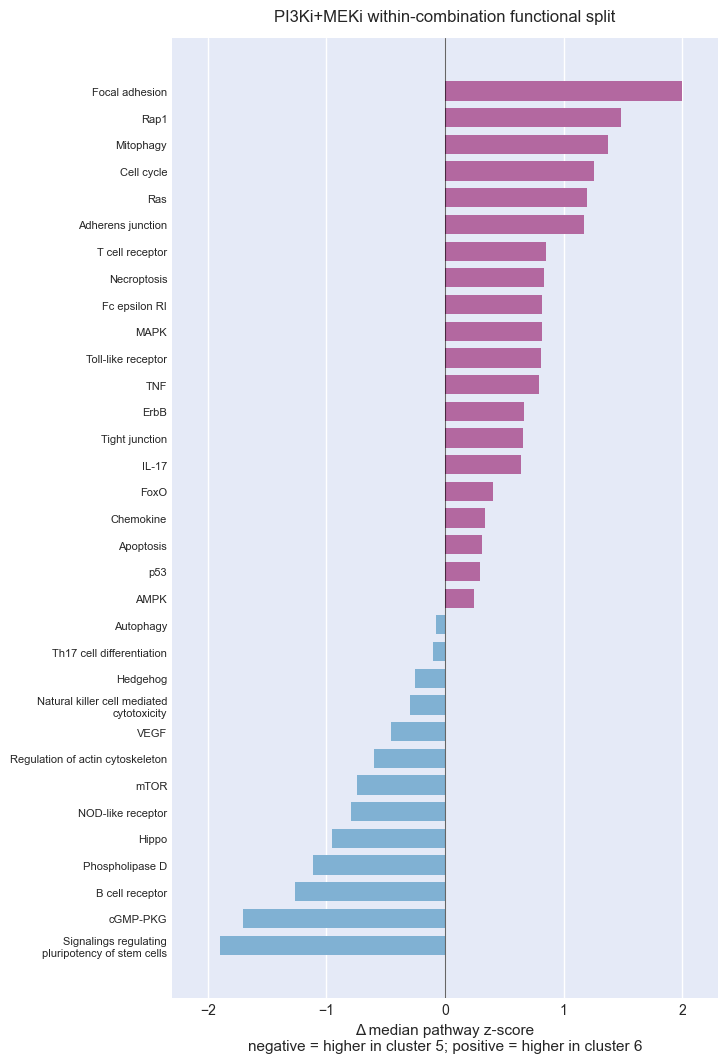

In [ ]:
is_target = Xz_t.index.get_level_values(0) == "PD_08_PD_10"
X_target = Xz_t.loc[is_target]
labels_target = labels_t.loc[is_target].astype(str)
keep = labels_target.isin(["5", "6"])
X_target = X_target.loc[keep]
labels_target = labels_target.loc[keep]

rows = []
for pw in X_target.columns:
    x = X_target.loc[labels_target == "5", pw]; y = X_target.loc[labels_target == "6", pw]
    stat, p = ranksums(x, y)
    rows.append({
        "Pathway": pw,
        "median_cluster_5": x.median(),
        "median_cluster_6": y.median(),
        "delta_6_vs_5": y.median() - x.median(),
        "pvalue": p,
        "n_cluster_5": len(x),
        "n_cluster_6": len(y)
    })

pi3k_mek_only_5v6 = pd.DataFrame(rows)
pi3k_mek_only_5v6["FDR"] = multipletests(pi3k_mek_only_5v6["pvalue"], method = "fdr_bh")[1]

# Horizontal bar plot — all significant pathways
fdr_thr = 0.05
col5 = "#80b1d3"   # cluster 5
col6 = "#B368A0"   # cluster 6

plot_df = pi3k_mek_only_5v6.copy()
plot_df = plot_df[plot_df["FDR"] < fdr_thr].copy()

if plot_df.empty:
    print("No significant pathways at FDR <", fdr_thr)
else:
    plot_df = plot_df.sort_values("delta_6_vs_5").copy()

    plot_df["Pathway_plot"] = (
        plot_df["Pathway"].astype(str)
        .str.replace(r"\s*-\s*Homo\s+sapiens\s*\(human\)\s*$", "", regex=True)
        .str.replace(" signaling pathway", "", regex=False)
        .str.replace(" pathway", "", regex=False)
        .str.replace(" - animal", "", regex=False)
    )

    plot_df["Pathway_plot"] = plot_df["Pathway_plot"].apply(
        lambda x: "\n".join(textwrap.wrap(x, width=32))
    )

    colors = np.where(plot_df["delta_6_vs_5"] > 0, col6, col5)

    fig_h = max(5, 0.32 * len(plot_df))
    fig, ax = plt.subplots(figsize=(7.2, fig_h))

    ax.barh(
        plot_df["Pathway_plot"],
        plot_df["delta_6_vs_5"],
        color=colors,
        edgecolor="none",
        height=0.72
    )

    xmax = plot_df["delta_6_vs_5"].abs().max()
    ax.set_xlim(-xmax * 1.15, xmax * 1.15)

    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)

    ax.set_xlabel(
        "Δ median pathway z-score\nnegative = higher in cluster 5; positive = higher in cluster 6",
        fontsize=11
    )
    ax.set_ylabel("")
    ax.set_title("PI3Ki+MEKi within-combination functional split", fontsize=12, pad=12)

    ax.set_facecolor("#e5eaf7")
    ax.set_axisbelow(True)
    ax.grid(True, axis="x", color="white", linewidth=1)

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=10)

    plt.tight_layout()
    fig.savefig("../figs/supp_figs/Supplementary_Figure_S7.png", dpi=300, bbox_inches="tight")
    plt.show()

#### **5.- Combo effect discordance**

Cross-cell-line cosine distances quantify how differently each combination reshapes pathway activity depending on the cellular context.

##### **5.1.- General discordance (Supplementary Figure S8)**

In [33]:
def combo_cosine_discordance(Xz, combo_level="perturbation",
                             cell_level="cell_line", min_cls=4):
    """Pairwise cosine distances between cell-line signatures per combo."""
    X = Xz.select_dtypes(include=[np.number]).rename(
        index=combo_to_drugs, level=combo_level)

    summary, maxpairs, allpairs = [], [], []
    for combo, idx in X.groupby(level=combo_level).groups.items():
        sub = X.loc[idx]
        cls = sub.index.get_level_values(cell_level).astype(str)
        ucls = cls.unique()
        if len(ucls) < min_cls:
            continue
        # Collapse duplicates (if any) by median
        mat = pd.DataFrame(sub.values, index=cls).groupby(level=0).median()
        ucls = mat.index.values

        D = cosine_distances(mat.values)
        ti, tj = np.triu_indices(len(D), k=1)
        dv = D[ti, tj]

        for i, j, d in zip(ti, tj, dv):
            allpairs.append({combo_level: combo, "cell_line_a": ucls[i],
                             "cell_line_b": ucls[j], "d_cos": d})
        summary.append({
            combo_level: combo, "n_cell_lines": len(ucls), "n_pairs": len(dv),
            "d_min": dv.min(), "d_median": np.median(dv), "d_mean": dv.mean(),
            "d_p75": np.quantile(dv, 0.75), "d_p90": np.quantile(dv, 0.90),
            "d_max": dv.max(),
        })
        k = dv.argmax()
        maxpairs.append({combo_level: combo, "cell_line_a": ucls[ti[k]],
                         "cell_line_b": ucls[tj[k]], "d_max": dv[k]})

    sum_df = pd.DataFrame(summary).sort_values("d_max", ascending=False).reset_index(drop=True)
    max_df = pd.DataFrame(maxpairs).merge(
        sum_df[[combo_level, "n_cell_lines", "n_pairs"]], on=combo_level)
    all_df = pd.DataFrame(allpairs)
    return sum_df, max_df, all_df


def plot_distances(allpairs_df, labels, pert_ids, combo_col="perturbation",
                   dcol="d_cos", fontsize=16, save_path=None):
    """Jitter strip-plot of pairwise cosine distances, colored by modal cluster."""
    df = allpairs_df[[combo_col, dcol]].dropna()
    order = df.groupby(combo_col)[dcol].median().sort_values().index.tolist()
    pos = {c: i for i, c in enumerate(order)}

    rng = np.random.default_rng(0)
    y = df[combo_col].map(pos).values + (rng.random(len(df)) - 0.5) * 0.6

    # Modal cluster per combo → colour
    combo2cl = (
        labels.groupby(pert_ids)
        .agg(lambda x: x.mode().iat[0]).astype(str)
        .rename(index=combo_to_drugs)
    )
    colors = df[combo_col].map(combo2cl.map(CLUSTER_COLORS)).fillna("#999").values

    fig, ax = plt.subplots(figsize=(14, 0.45 * len(order) + 3))
    ax.scatter(df[dcol].values, y, s=6, alpha=0.3, c=colors, lw=0)
    used = set(combo2cl.values)
    ax.legend(
        handles=[Patch(fc=v, ec="none", label=f"Cluster {k}")
                 for k, v in CLUSTER_COLORS.items() if k in used],
        title="Functional cluster", title_fontsize=fontsize,
        loc="lower right", frameon=False, fontsize=fontsize,
    )
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=fontsize)
    ax.tick_params(axis="x", labelsize=fontsize)
    ax.set_xlabel("Cosine distance between cell-line signatures", fontsize=fontsize)
    ax.set_ylabel("Combination", fontsize=fontsize)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    if save_path:
        for ext in (".png", ".pdf"):
            plt.savefig(save_path + ext, dpi=300, bbox_inches="tight")
    plt.show()


def compare_responses(pw_scores, syn_scores, cond1, cond2):
    """Compare pathway & synergy scores between two cell-line/combo conditions."""
    (combo1, cl1), (combo2, cl2) = cond1, cond2

    def _pw(combo, cl):
        m = (pw_scores["cell_line"] == cl) & (pw_scores["perturbation"] == combo)
        return (pw_scores.loc[m, ["Pathway_ID", "Pathway_Name", "score"]]
                .rename(columns={"score": f"score_{cl}"}))

    merged = _pw(combo1, cl1).merge(_pw(combo2, cl2), on=["Pathway_ID", "Pathway_Name"])
    s1, s2 = f"score_{cl1}", f"score_{cl2}"
    merged["delta"] = merged[s2] - merged[s1]
    merged["fold_change"] = merged[s2] / merged[s1].replace(0, np.nan).abs()
    merged["sign_flip"] = ((merged[s1] * merged[s2]) < 0).astype(int)

    # Synergy excess
    def _syn(combo, cl):
        m = (syn_scores["cell_line"] == cl) & (syn_scores["Perturbation"] == combo)
        return syn_scores.loc[m, "Excess"].iloc[0]

    merged[f"Bliss_{cl1}"] = _syn(combo1, cl1)
    merged[f"Bliss_{cl2}"] = _syn(combo2, cl2)
    return merged.sort_values("delta", key=abs, ascending=False).reset_index(drop=True)

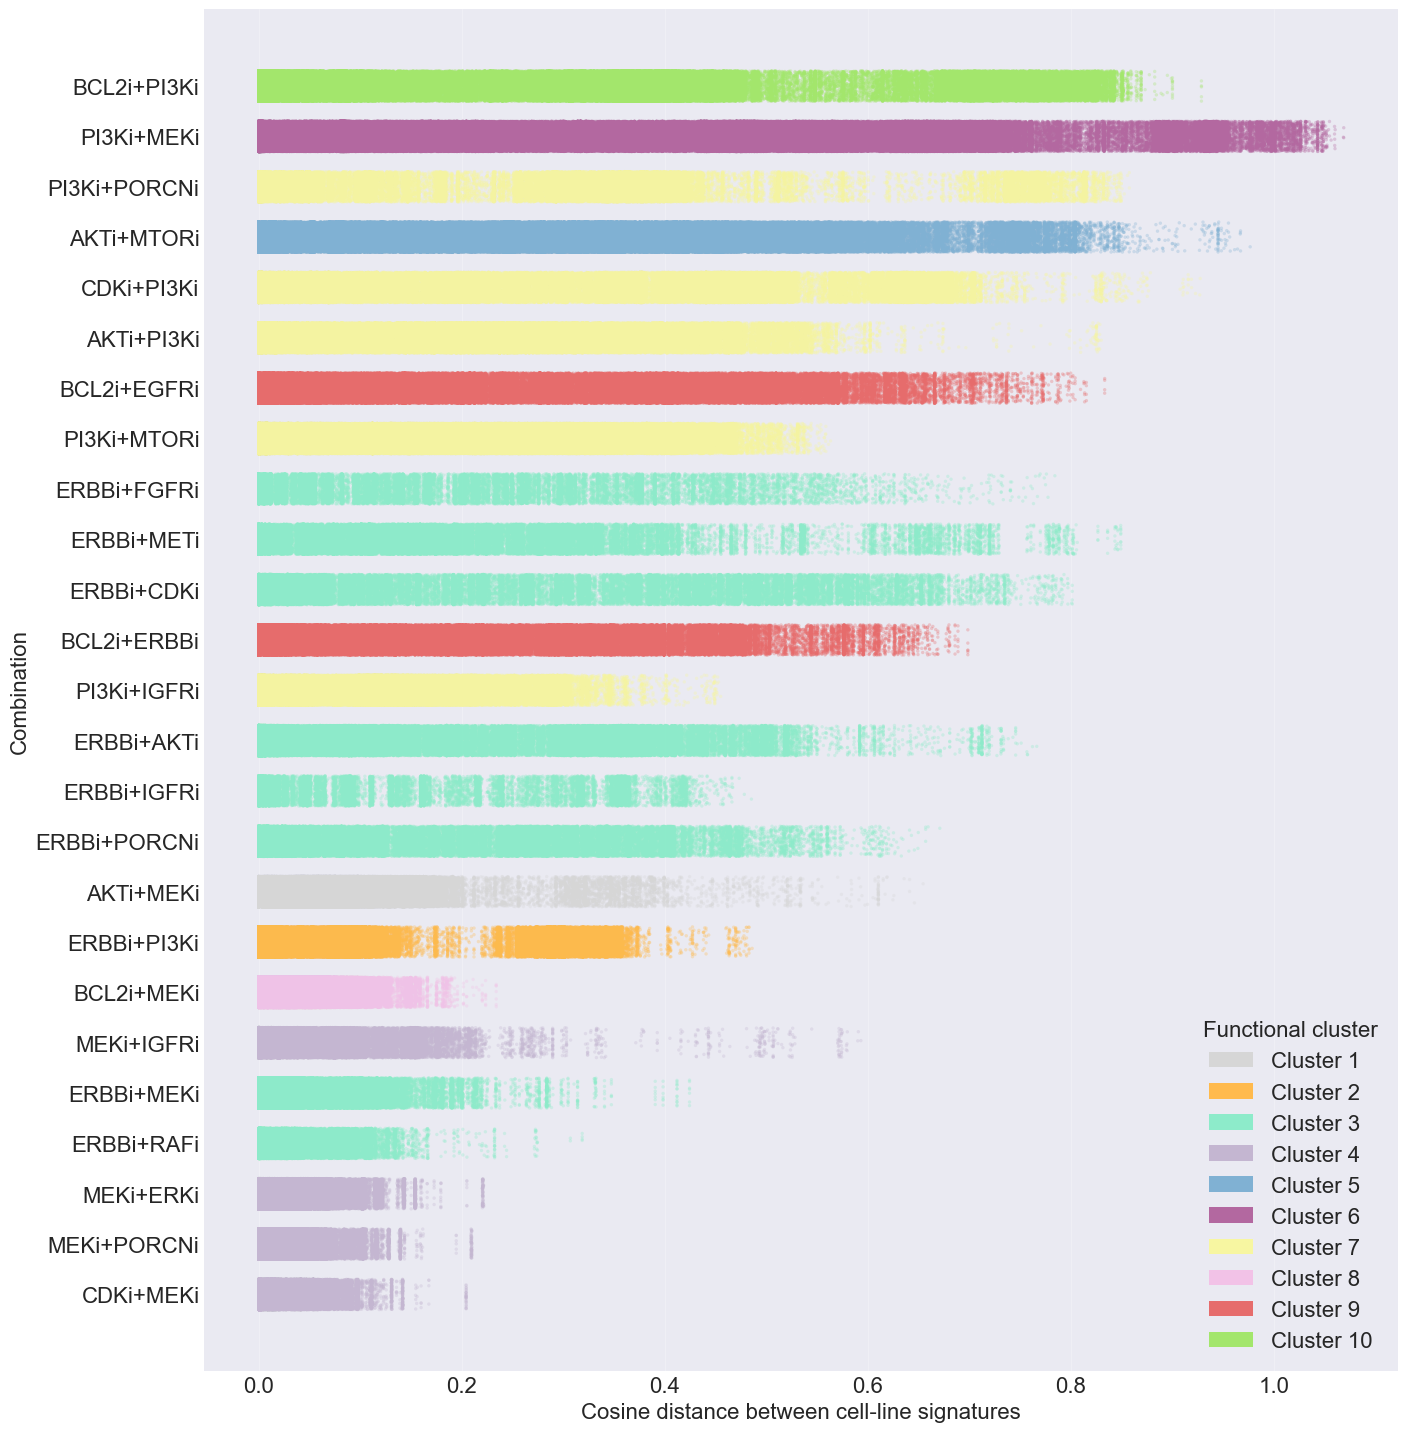

In [ ]:
summary_df, maxpair_df, allpairs_df = combo_cosine_discordance(
    Xz_cl, combo_level="perturbation", cell_level="cell_line", min_cls=4,
)
plot_distances(allpairs_df, labels_t, pert_ids_t,
               save_path="../figs/supp_figs/Supplementary_Figure_S8.png")

##### **5.2.- Cell-line comparison: BCL2i + PI3Ki (Figure 4A)**

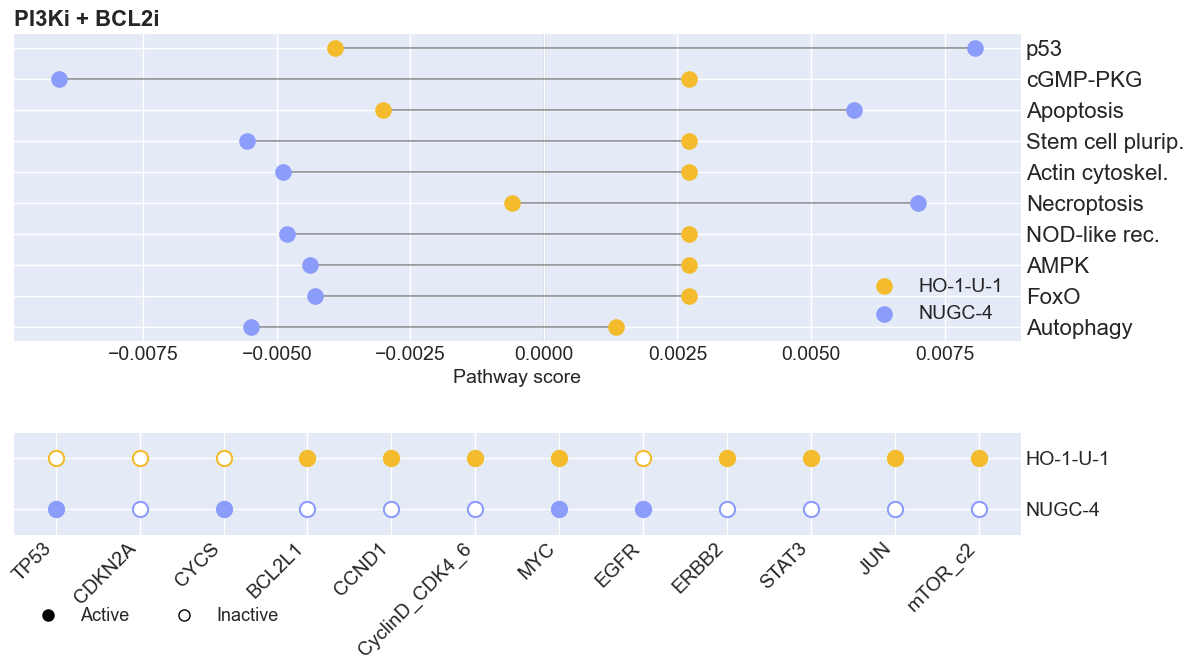

In [ ]:
# --- compare two cell lines --------------------------------------------------
pw_csv  = pd.read_csv("../results/pathway_scores.csv")
syn_csv = pd.read_csv("../results/synergy_scores.csv")

cl_comp = compare_responses(pw_csv, syn_csv,
                            ("PD_01_PD_08", "HO1U1"),
                            ("PD_01_PD_08", "NUGC4"))
cl_comp = cl_comp[cl_comp["fold_change"].abs() > 1.5].reset_index(drop=True)
cl_comp["Pathway_Name"] = (
    cl_comp["Pathway_Name"]
    .str.replace(r"\s*[–-]\s*Homo\s+sapiens.*$", "", regex=True)
    .str.replace(r"\s*-\s*animal$", "", regex=True)
    .replace(PATHWAY_ABBREV)
)

# --- constants ---------------------------------------------------------------
CL1, CL2 = "HO1U1", "NUGC4"
CL1_D, CL2_D = "HO-1-U-1", "NUGC-4"
CL_COL = {CL1_D: "#f4bc2c", CL2_D: "#8c9cfb"}

TRAINING = {
    CL2_D: {"CDKN2A": 0, "CYCS": 1, "EGFR": 1, "MYC": 1, "TP53": 1},
    CL1_D: {"BCL2L1": 1, "CCND1": 1, "CyclinD_CDK4_6": 1, "ERBB2": 1,
             "JUN": 1, "STAT3": 1, "MYC": 1, "TP53": 0, "mTOR_c2": 1},
}
df_tr = pd.DataFrame(TRAINING)
GENES = [g for g in ["TP53", "CDKN2A", "CYCS", "BCL2L1", "CCND1",
                      "CyclinD_CDK4_6", "MYC", "EGFR", "ERBB2",
                      "STAT3", "JUN", "mTOR_c2"] if g in df_tr.index]
CLS_ORDER = [CL1_D, CL2_D]

# --- Panel A data ------------------------------------------------------------
d = cl_comp.iloc[:10].sort_values("delta", key=abs)
y = np.arange(len(d))
x1 = d[f"score_{CL1}"].values
x2 = d[f"score_{CL2}"].values

# --- figure ------------------------------------------------------------------
fs = 14
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 6.5), gridspec_kw={"height_ratios": [3, 1]})
fig.subplots_adjust(hspace=0.45)

ax1.set_facecolor("#e5eaf7"); ax1.set_axisbelow(True)
ax1.grid(True, color="white", linewidth=1)
ax1.axvline(0, lw=1, color="k", alpha=0.35, zorder=0)
for i in range(len(d)):
    ax1.plot([x1[i], x2[i]], [y[i], y[i]], lw=1.4, c="k", alpha=0.35, zorder=1)
ax1.scatter(x1, y, s=120, color=CL_COL[CL1_D], zorder=4, label=CL1_D)
ax1.scatter(x2, y, s=120, color=CL_COL[CL2_D], zorder=4, label=CL2_D)
ax1.set_yticks(y)
ax1.set_yticklabels(d["Pathway_Name"], fontsize=fs + 2)
ax1.tick_params(axis="x", labelsize=fs, length=0)
ax1.tick_params(axis="y", length=0)
ax1.set_xlabel("Pathway score", fontsize=fs)
ax1.yaxis.tick_right(); ax1.yaxis.set_label_position("right")
ax1.set_title("PI3Ki + BCL2i", loc="left", fontsize=fs + 2, fontweight="bold")
ax1.legend(frameon=False, loc="lower right", fontsize=fs)
for s in ("top", "right", "left"):
    ax1.spines[s].set_visible(False)

# Panel B — training node states
ax2.set_facecolor("#e5eaf7"); ax2.set_axisbelow(True)
ax2.grid(True, color="white", linewidth=1)
for yi, cl in enumerate(CLS_ORDER):
    for xi, gene in enumerate(GENES):
        val = df_tr.loc[gene, cl]
        ax2.scatter(xi, yi, s=120,
                    facecolors=CL_COL[cl] if val == 1 else "white",
                    edgecolors=CL_COL[cl], lw=1.5)
ax2.set_xlim(-0.5, len(GENES) - 0.5)
ax2.set_ylim(-0.5, len(CLS_ORDER) - 0.5)
ax2.invert_yaxis()
ax2.set_xticks(range(len(GENES)))
ax2.set_xticklabels(GENES, rotation=45, ha="right", fontsize=fs)
ax2.set_yticks(range(len(CLS_ORDER)))
ax2.set_yticklabels(CLS_ORDER, fontsize=fs)
ax2.yaxis.tick_right(); ax2.yaxis.set_label_position("right")
for sp in ax2.spines.values():
    sp.set_visible(False)
ax2.tick_params(length=0)
ax2.legend(
    handles=[
        Line2D([], [], marker="o", ls="", mfc="k", mec="k", ms=8, label="Active"),
        Line2D([], [], marker="o", ls="", mfc="w", mec="k", ms=8, label="Inactive"),
    ],
    frameon=False, fontsize=fs - 1, loc="upper left",
    bbox_to_anchor=(0, -0.55), ncol=2,
)


plt.savefig("../figs/panels/Figure_4A.png", dpi=300, bbox_inches="tight")
plt.show()